## 1. Forecasting Data Preparation

### 1.1 Load and validate the primary processed dataset

The forecasting analysis uses the same primary water-level series as ERP_01: short internal gaps have been interpolated according to the preprocessing rule, while retained long gaps remain missing. No fully interpolated water-level dataset is used here.

In [1]:
import warnings
import time
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox


# Define project directories
PROJECT_ROOT = Path.cwd().parent

processed_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

outputs_path = (
    PROJECT_ROOT
    / "outputs"
)

forecast_output_dir = (
    outputs_path
    / "forecasting_results"
)

figures_path = (
    outputs_path
    / "figures"
)

forecast_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

figures_path.mkdir(
    parents=True,
    exist_ok=True
)


# Load the primary dataset generated by Notebook 01
primary_data_file = (
    processed_path
    / "water_climate_10_lakes_primary.csv"
)

water_climate = pd.read_csv(
    primary_data_file,
    parse_dates=["Date"]
)

### 1.2 Construct the regular daily water-level matrix

In [2]:
lake_order = [
    "Lake Superior",
    "Lake Huron",
    "Lake Michigan",
    "Lake Erie",
    "Lake Ontario",
    "Lake Woods",
    "Great Salt Lake",
    "Lake Champlain",
    "Red Lake",
    "Lake Tahoe"
]

lake_level_wide = (
    water_climate
    .pivot(
        index="Date",
        columns="Lake",
        values="Lake_Level_ft"
    )
    .sort_index()
    .reindex(columns=lake_order)
    .asfreq("D")
)

print("Wide water-level matrix shape:", lake_level_wide.shape)
print()
print("Missing values by lake:")
print(lake_level_wide.isna().sum())

display(lake_level_wide.head())

Wide water-level matrix shape: (7305, 10)

Missing values by lake:
Lake
Lake Superior       31
Lake Huron          30
Lake Michigan        0
Lake Erie            0
Lake Ontario        30
Lake Woods          21
Great Salt Lake      0
Lake Champlain       0
Red Lake           167
Lake Tahoe           0
dtype: int64


Lake,Lake Superior,Lake Huron,Lake Michigan,Lake Erie,Lake Ontario,Lake Woods,Great Salt Lake,Lake Champlain,Red Lake,Lake Tahoe
Date,,,,,,,,,,
2006-01-01,601.63,576.83,577.54,569.96,244.54,59.40,4195.78,97.83,74.43,5.49
2006-01-02,601.48,576.95,577.49,570.19,244.54,59.38,4195.76,97.82,74.42,5.62
2006-01-03,601.33,576.97,577.18,570.52,244.57,59.35,4195.77,97.80,74.41,5.64
2006-01-04,601.32,576.79,577.21,571.10,244.60,59.32,4195.88,97.75,74.39,5.65
2006-01-05,601.33,576.96,577.12,570.76,244.65,59.31,4195.89,97.71,74.39,5.66


### 1.3 Lake Superior prototype and chronological model-development periods

Lake Superior is retained as the prototype used to demonstrate the modelling workflow. All final model-selection functions are subsequently applied consistently to all ten lakes.

In [3]:
target_lake = "Lake Superior"

lake_series = (
    lake_level_wide[target_lake]
    .astype(float)
    .sort_index()
    .asfreq("D")
)

PARAMETER_TRAIN_START = "2006-01-01"
PARAMETER_TRAIN_END = "2018-12-31"
VALIDATION_START = "2019-01-01"
VALIDATION_END = "2021-12-31"
FINAL_TEST_START = "2022-01-01"
FINAL_TEST_END = "2025-12-31"

parameter_train = lake_series.loc[
    PARAMETER_TRAIN_START:PARAMETER_TRAIN_END
].copy()

validation = lake_series.loc[
    VALIDATION_START:VALIDATION_END
].copy()

full_pretest = lake_series.loc[
    PARAMETER_TRAIN_START:VALIDATION_END
].copy()

final_test = lake_series.loc[
    FINAL_TEST_START:FINAL_TEST_END
].copy()

print("Target lake:", target_lake)
print("Parameter training:", parameter_train.index.min(), "to", parameter_train.index.max())
print("Validation:", validation.index.min(), "to", validation.index.max())
print("Full pre-test refit period:", full_pretest.index.min(), "to", full_pretest.index.max())
print("Final test:", final_test.index.min(), "to", final_test.index.max())

print()
print("Missing values:")
print("Parameter training:", parameter_train.isna().sum())
print("Validation:", validation.isna().sum())
print("Final test:", final_test.isna().sum())

Target lake: Lake Superior
Parameter training: 2006-01-01 00:00:00 to 2018-12-31 00:00:00
Validation: 2019-01-01 00:00:00 to 2021-12-31 00:00:00
Full pre-test refit period: 2006-01-01 00:00:00 to 2021-12-31 00:00:00
Final test: 2022-01-01 00:00:00 to 2025-12-31 00:00:00

Missing values:
Parameter training: 0
Validation: 0
Final test: 31


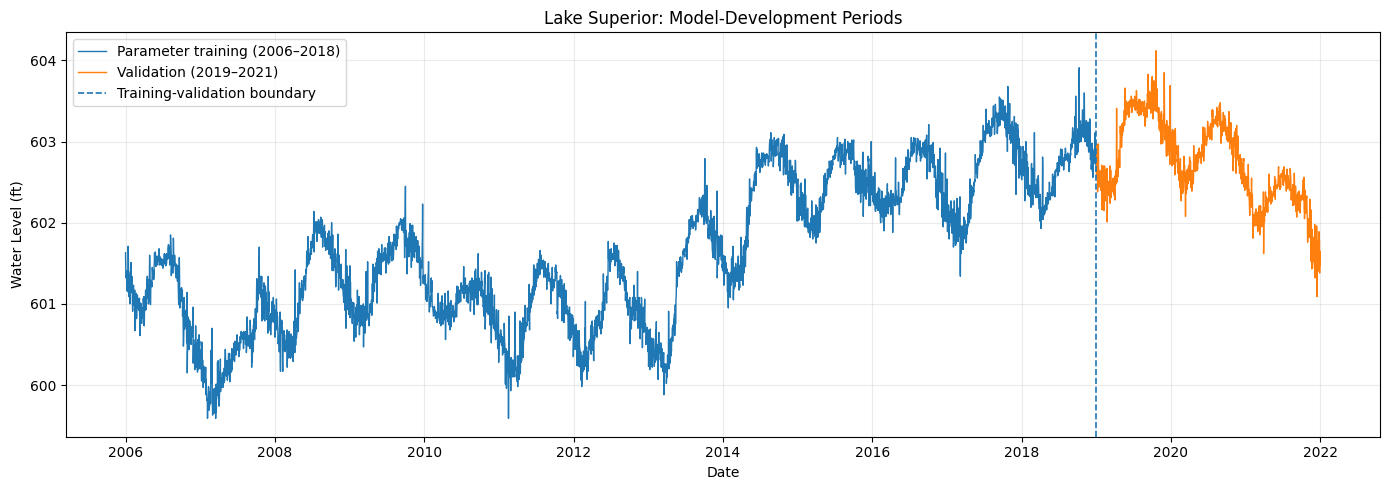

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    parameter_train.index,
    parameter_train,
    label="Parameter training (2006–2018)",
    linewidth=1
)

ax.plot(
    validation.index,
    validation,
    label="Validation (2019–2021)",
    linewidth=1
)

ax.axvline(
    pd.Timestamp(VALIDATION_START),
    linestyle="--",
    linewidth=1.2,
    label="Training-validation boundary"
)

ax.set_title(
    f"{target_lake}: Model-Development Periods"
)
ax.set_xlabel("Date")
ax.set_ylabel("Water Level (ft)")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 2. Time-Series Diagnostics

Diagnostics are calculated using the parameter-training period only so that validation and final-test information cannot influence model specification. Retained long gaps are not filled solely for diagnostics; where necessary, the longest contiguous observed daily segment is used.

In [5]:
def longest_observed_segment(series):
    """Return the longest contiguous non-missing daily segment."""

    series = (
        pd.Series(series)
        .astype(float)
        .sort_index()
        .asfreq("D")
    )

    observed = series.notna()

    if not observed.any():
        raise ValueError(
            "No observed values are available."
        )

    group_id = (
        observed
        .ne(observed.shift(fill_value=False))
        .cumsum()
    )

    segments = [
        segment
        for _, segment in (
            series[observed]
            .groupby(group_id[observed])
        )
    ]

    return max(
        segments,
        key=len
    )

### 2.1 Seasonal decomposition

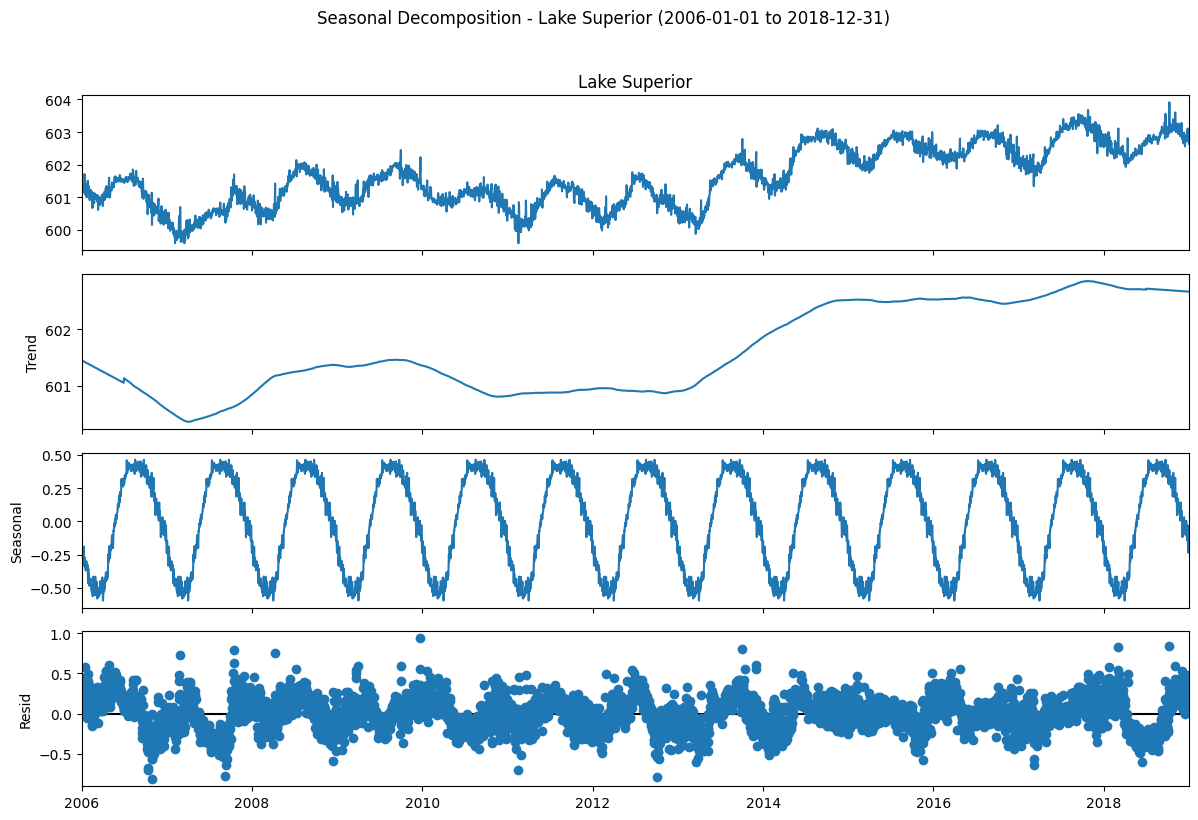

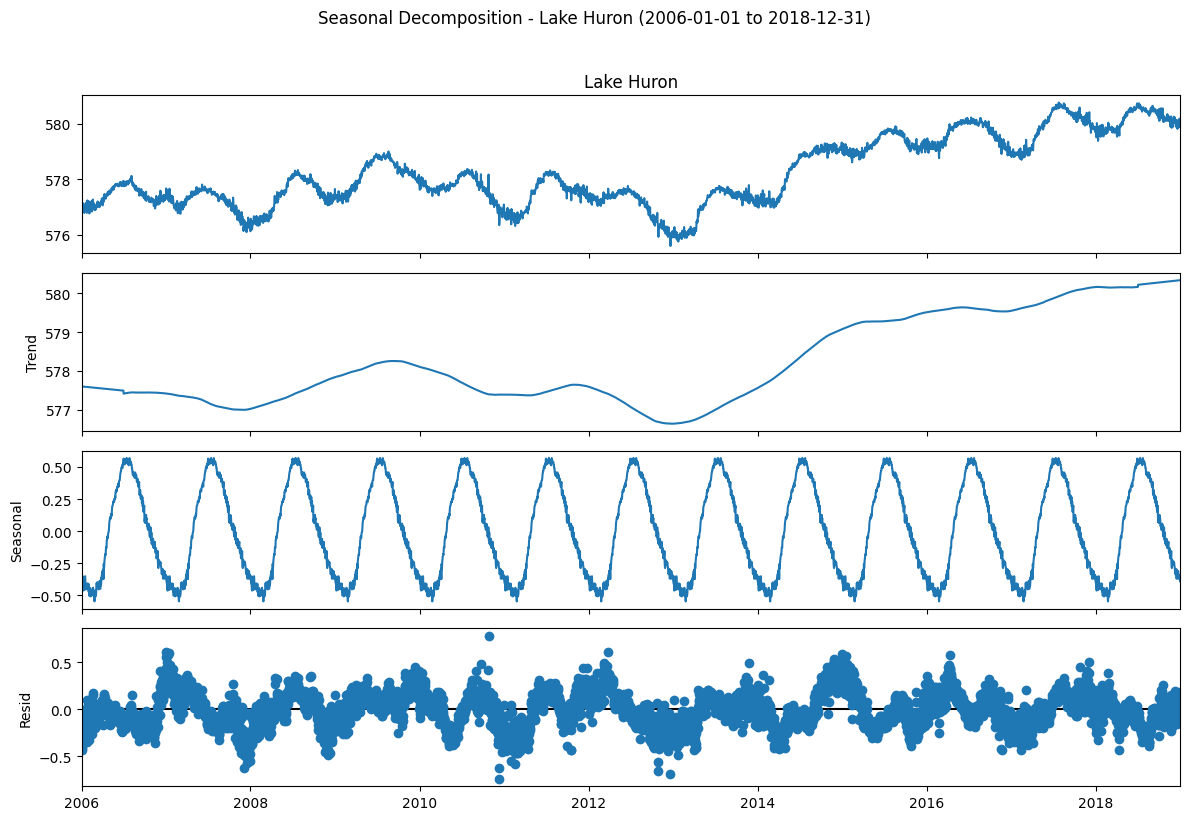

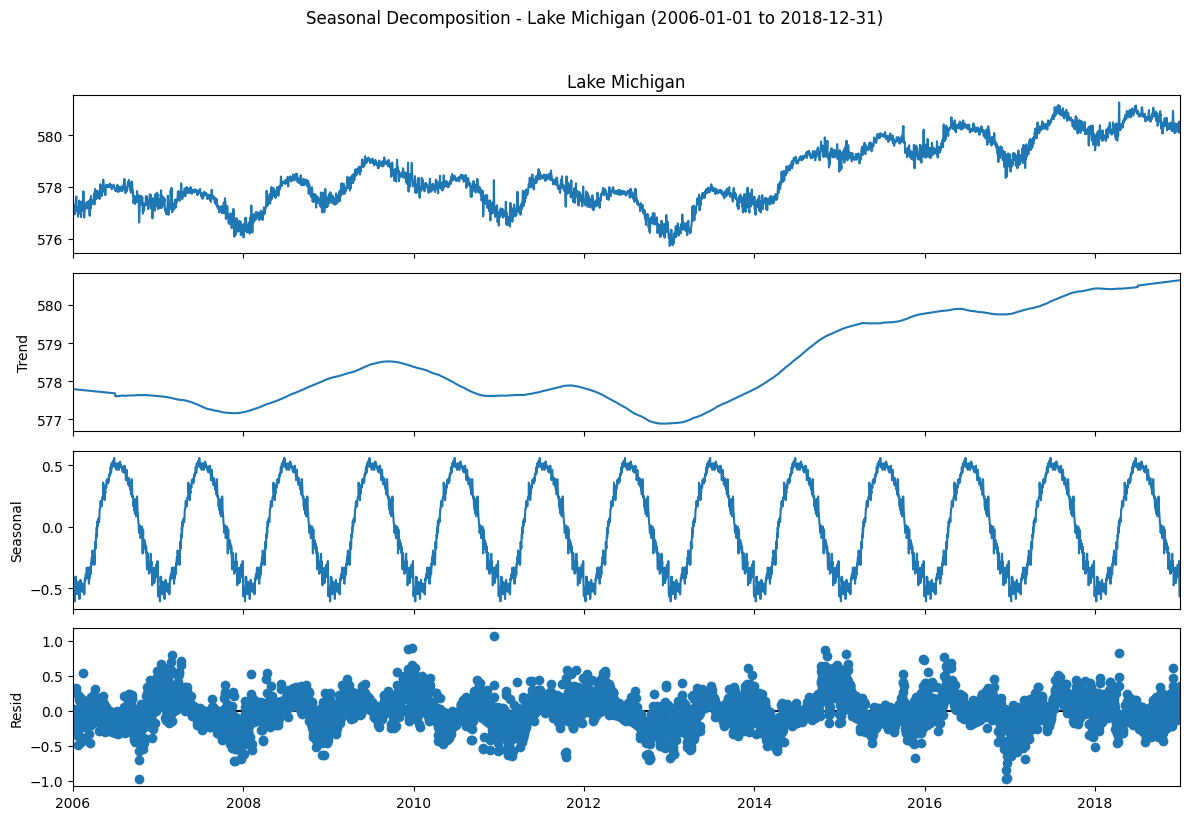

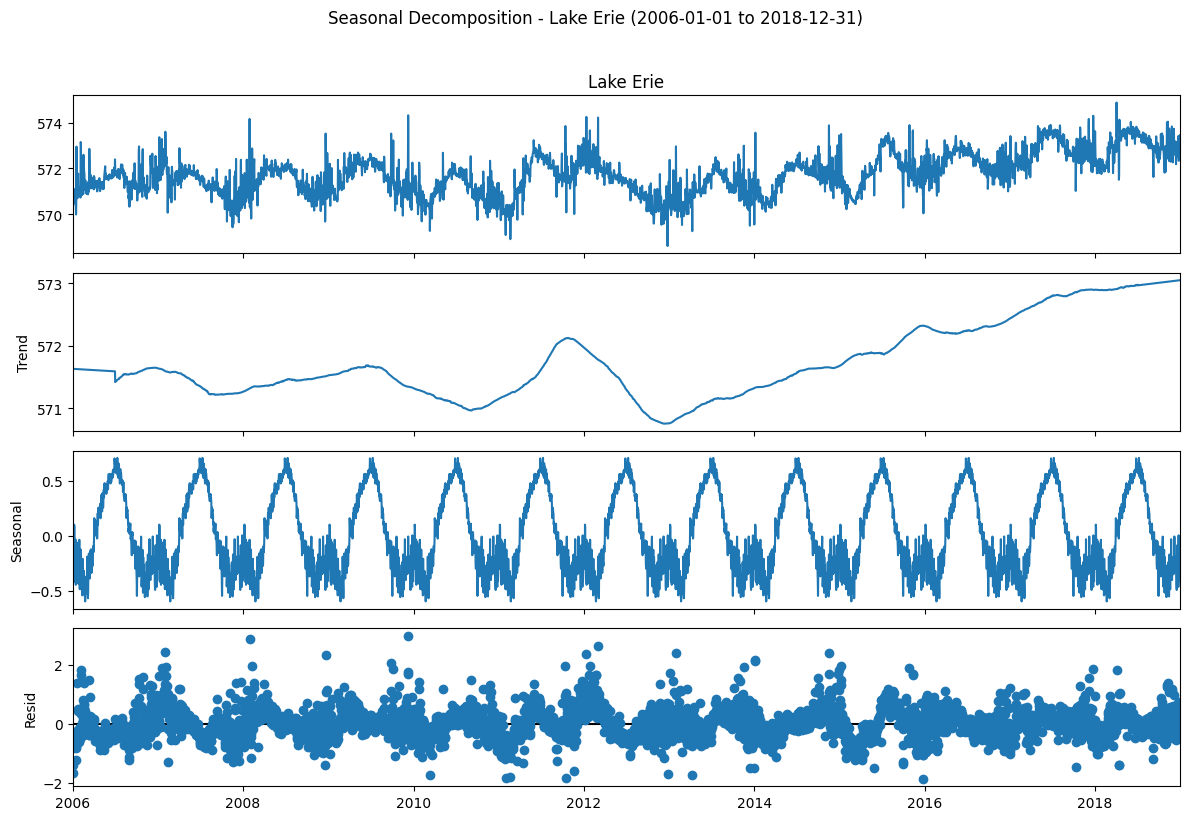

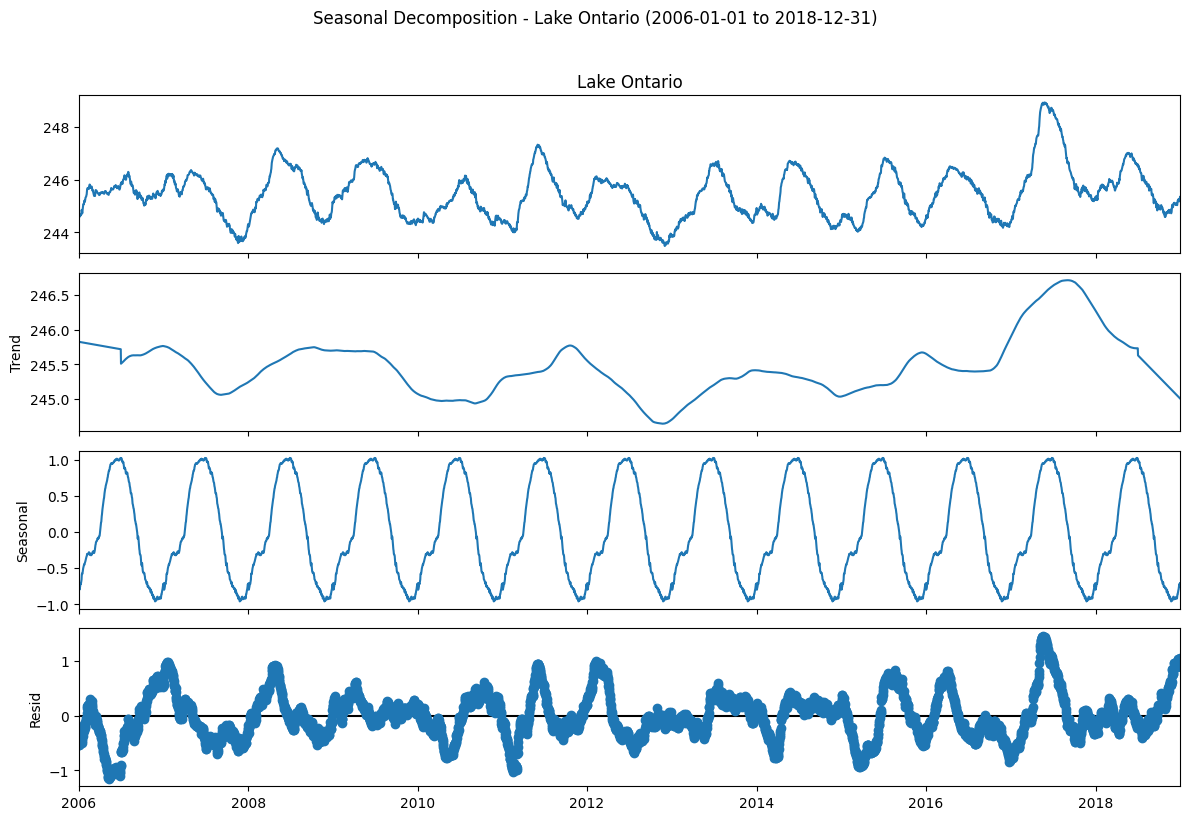

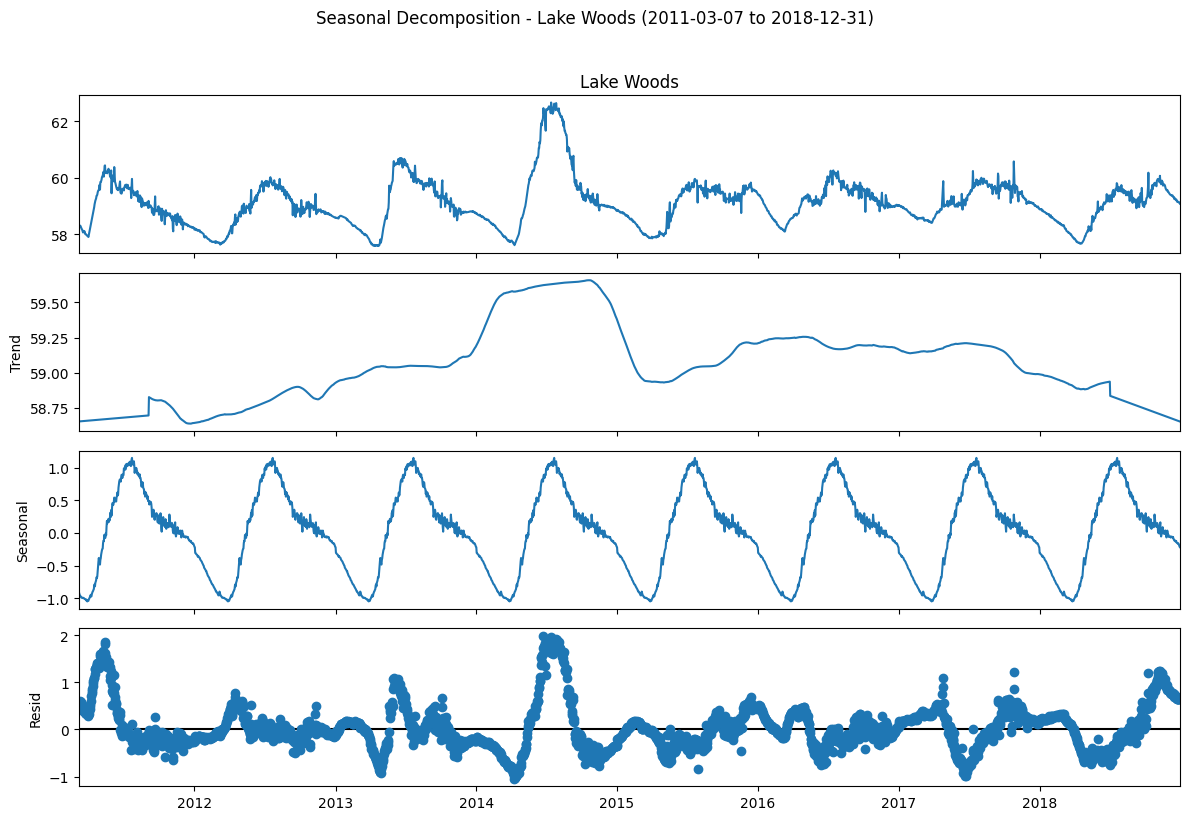

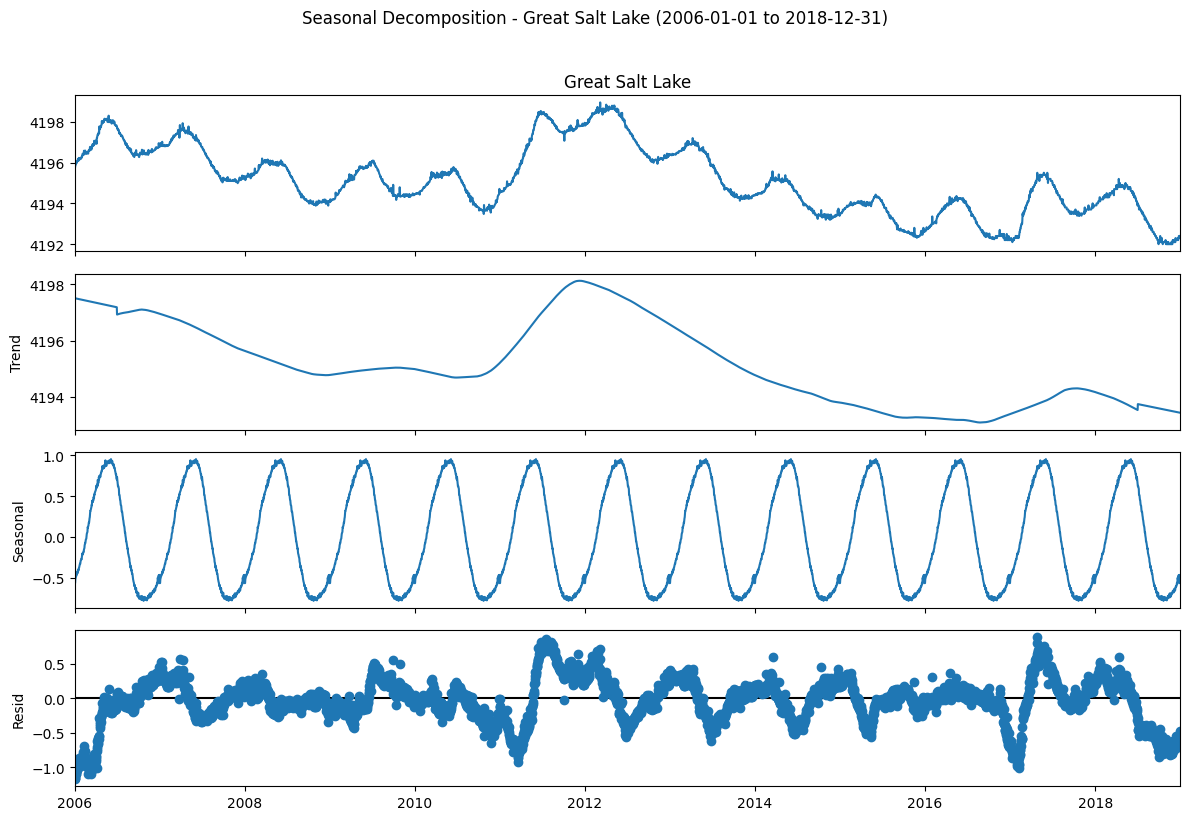

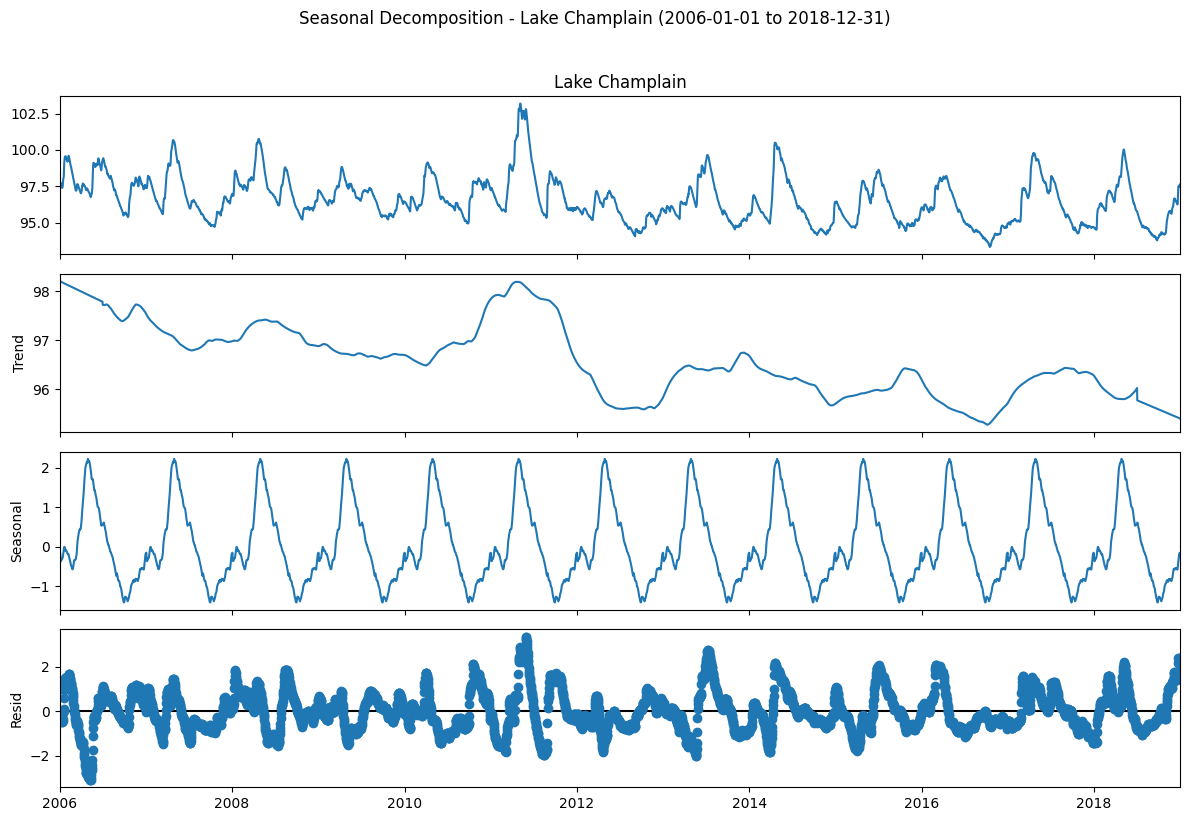

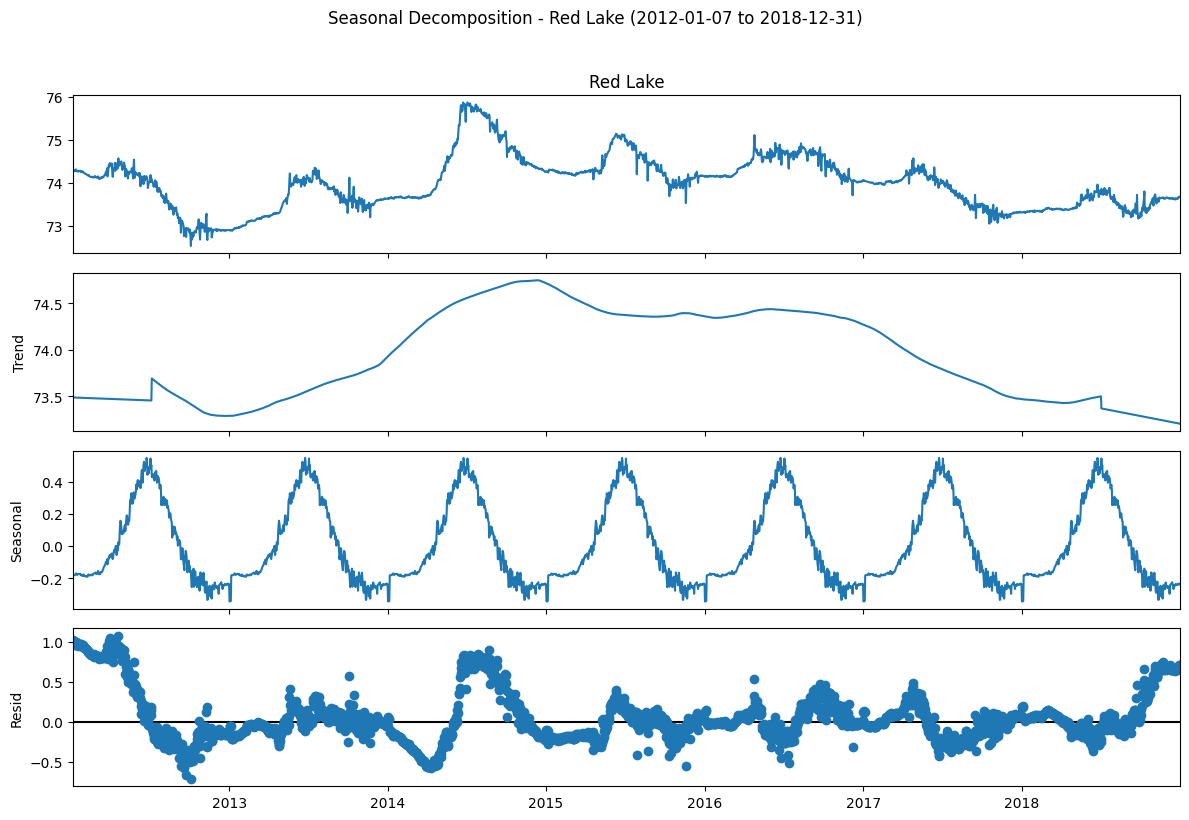

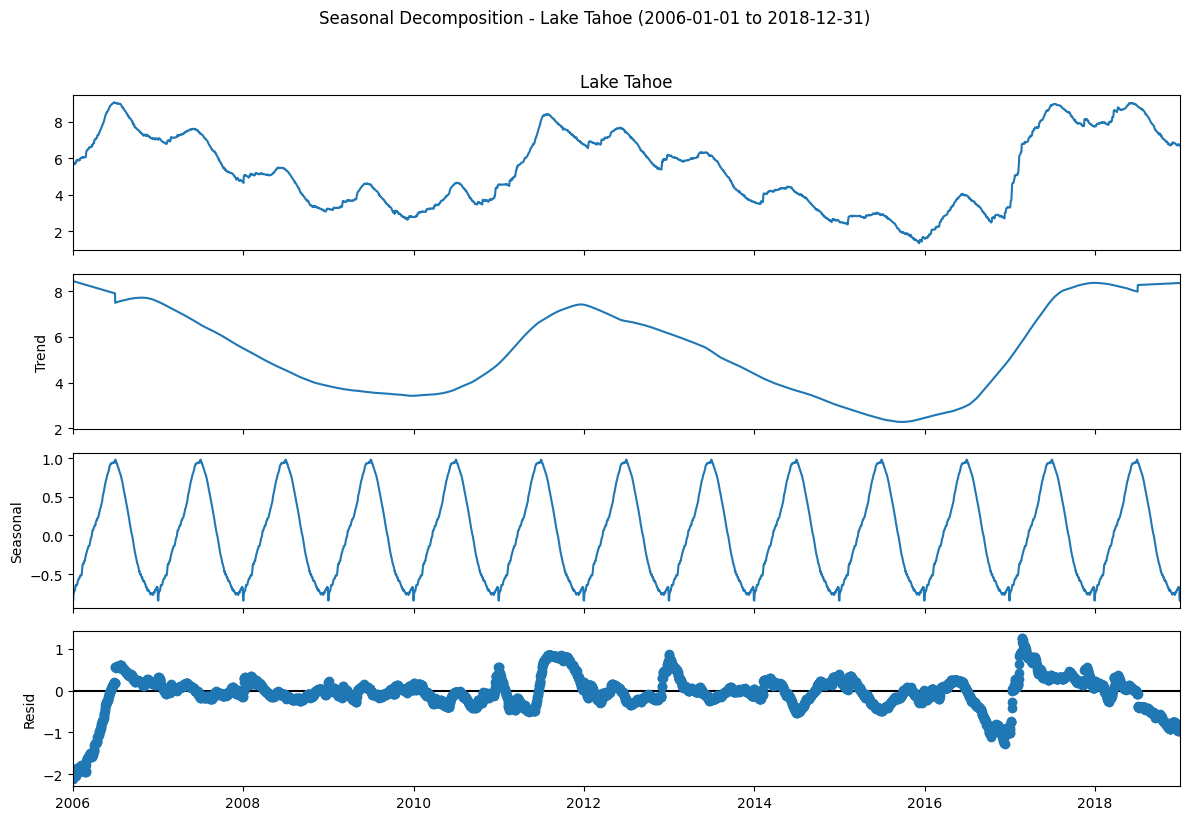

,Lake,Segment Start,Segment End,N
0,Lake Superior,2006-01-01,2018-12-31,4748
1,Lake Huron,2006-01-01,2018-12-31,4748
2,Lake Michigan,2006-01-01,2018-12-31,4748
3,Lake Erie,2006-01-01,2018-12-31,4748
4,Lake Ontario,2006-01-01,2018-12-31,4748
5,Lake Woods,2011-03-07,2018-12-31,2857
6,Great Salt Lake,2006-01-01,2018-12-31,4748
7,Lake Champlain,2006-01-01,2018-12-31,4748
8,Red Lake,2012-01-07,2018-12-31,2551
9,Lake Tahoe,2006-01-01,2018-12-31,4748


In [6]:
seasonal_decomposition_summary = []

for lake in lake_order:

    training_series = (
        lake_level_wide[lake]
        .loc[
            PARAMETER_TRAIN_START:
            PARAMETER_TRAIN_END
        ]
        .astype(float)
    )

    diagnostic_segment = (
        longest_observed_segment(
            training_series
        )
    )

    seasonal_decomposition_summary.append({
        "Lake": lake,
        "Segment Start": diagnostic_segment.index.min(),
        "Segment End": diagnostic_segment.index.max(),
        "N": len(diagnostic_segment)
    })

    if len(diagnostic_segment) < 730:
        print(
            f"{lake}: decomposition skipped because the "
            "longest contiguous segment is shorter than "
            "two annual cycles."
        )
        continue

    decomposition = seasonal_decompose(
        diagnostic_segment,
        model="additive",
        period=365,
        extrapolate_trend="freq"
    )

    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle(
        f"Seasonal Decomposition - {lake} "
        f"({diagnostic_segment.index.min().date()} to "
        f"{diagnostic_segment.index.max().date()})",
        y=1.02
    )

    plt.tight_layout()
    plt.show()

seasonal_decomposition_summary = pd.DataFrame(
    seasonal_decomposition_summary
)

display(seasonal_decomposition_summary)

### 2.2 Augmented Dickey–Fuller stationarity assessment

The differencing order is determined from the parameter-training data. If the level series is non-stationary at the 5% level, the first-differenced series is tested and `d=1` is used for subsequent ARIMA-family models.

In [7]:
def choose_differencing_order(
    train_series,
    alpha=0.05
):
    """Choose d=0 or d=1 using ADF tests on a contiguous training segment."""

    diagnostic_series = (
        longest_observed_segment(
            train_series
        )
    )

    level_adf = adfuller(
        diagnostic_series,
        autolag="AIC"
    )

    level_pvalue = level_adf[1]

    if level_pvalue < alpha:
        return {
            "d": 0,
            "Level ADF Statistic": level_adf[0],
            "Level ADF p-value": level_pvalue,
            "First Difference ADF Statistic": np.nan,
            "First Difference ADF p-value": np.nan,
            "ADF Segment Start": diagnostic_series.index.min(),
            "ADF Segment End": diagnostic_series.index.max(),
            "ADF N": len(diagnostic_series)
        }

    first_difference = (
        diagnostic_series
        .diff()
        .dropna()
    )

    difference_adf = adfuller(
        first_difference,
        autolag="AIC"
    )

    return {
        "d": 1,
        "Level ADF Statistic": level_adf[0],
        "Level ADF p-value": level_pvalue,
        "First Difference ADF Statistic": difference_adf[0],
        "First Difference ADF p-value": difference_adf[1],
        "ADF Segment Start": diagnostic_series.index.min(),
        "ADF Segment End": diagnostic_series.index.max(),
        "ADF N": len(diagnostic_series)
    }

In [8]:
adf_rows = []

for lake in lake_order:

    training_series = (
        lake_level_wide[lake]
        .loc[
            PARAMETER_TRAIN_START:
            PARAMETER_TRAIN_END
        ]
    )

    result = choose_differencing_order(
        training_series
    )

    adf_rows.append({
        "Lake": lake,
        **result
    })

adf_summary = pd.DataFrame(adf_rows)

display(adf_summary)

,Lake,d,Level ADF Statistic,Level ADF p-value,First Difference ADF Statistic,First Difference ADF p-value,ADF Segment Start,ADF Segment End,ADF N
0,Lake Superior,1,-2.066951,2.580097e-01,-9.314146,1.029953e-15,2006-01-01,2018-12-31,4748
1,Lake Huron,1,-1.754312,4.033685e-01,-8.508433,1.185362e-13,2006-01-01,2018-12-31,4748
2,Lake Michigan,1,-1.431341,5.671619e-01,-10.909375,1.106936e-19,2006-01-01,2018-12-31,4748
3,Lake Erie,0,-3.063900,2.934267e-02,NaN,NaN,2006-01-01,2018-12-31,4748
4,Lake Ontario,0,-5.220993,7.964643e-06,NaN,NaN,2006-01-01,2018-12-31,4748
5,Lake Woods,0,-6.132473,8.337700e-08,NaN,NaN,2011-03-07,2018-12-31,2857
6,Great Salt Lake,0,-3.584426,6.065837e-03,NaN,NaN,2006-01-01,2018-12-31,4748
7,Lake Champlain,0,-5.637592,1.054361e-06,NaN,NaN,2006-01-01,2018-12-31,4748
8,Red Lake,1,-2.726670,6.953586e-02,-5.964466,2.002976e-07,2012-01-07,2018-12-31,2551
9,Lake Tahoe,0,-2.865173,4.955032e-02,NaN,NaN,2006-01-01,2018-12-31,4748


### 2.3 ACF and PACF

ACF and PACF are plotted on the stationary representation selected by the ADF test: levels when `d=0`, and first differences when `d=1`. ACF is shown to 365 days to reveal short-term and annual dependence; PACF is limited to 60 days to focus on short-term autoregressive structure.

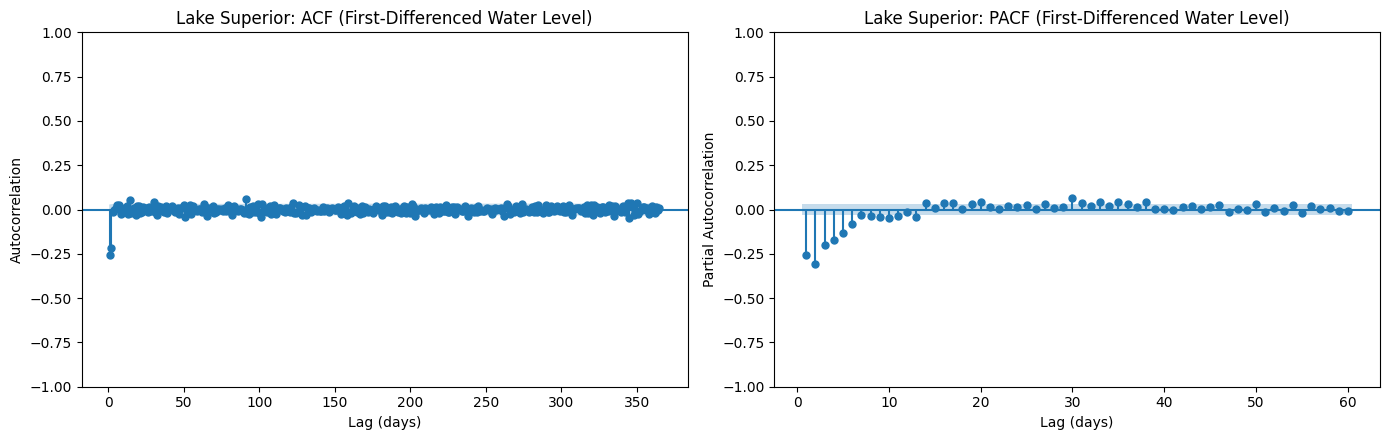

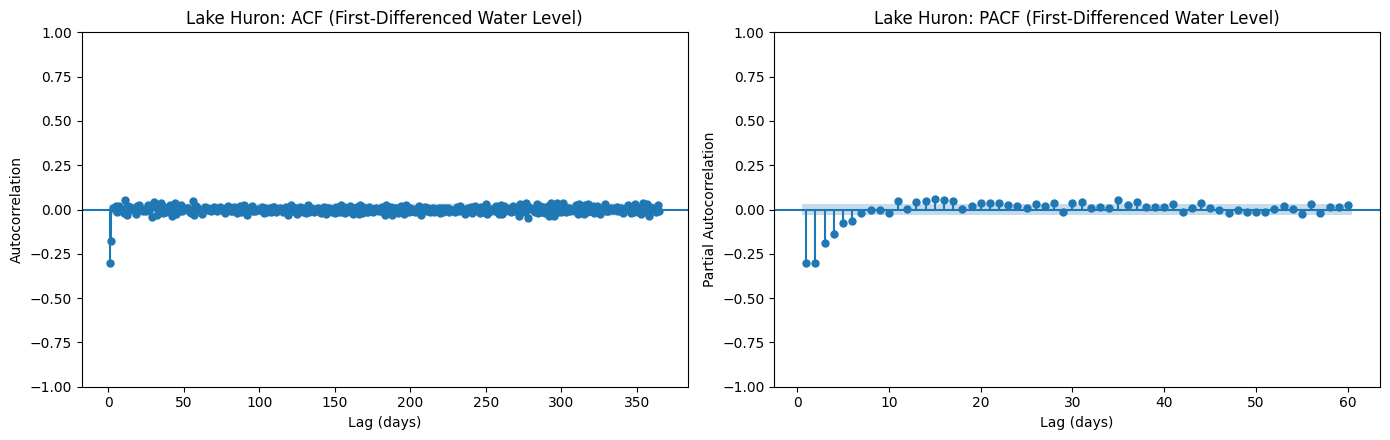

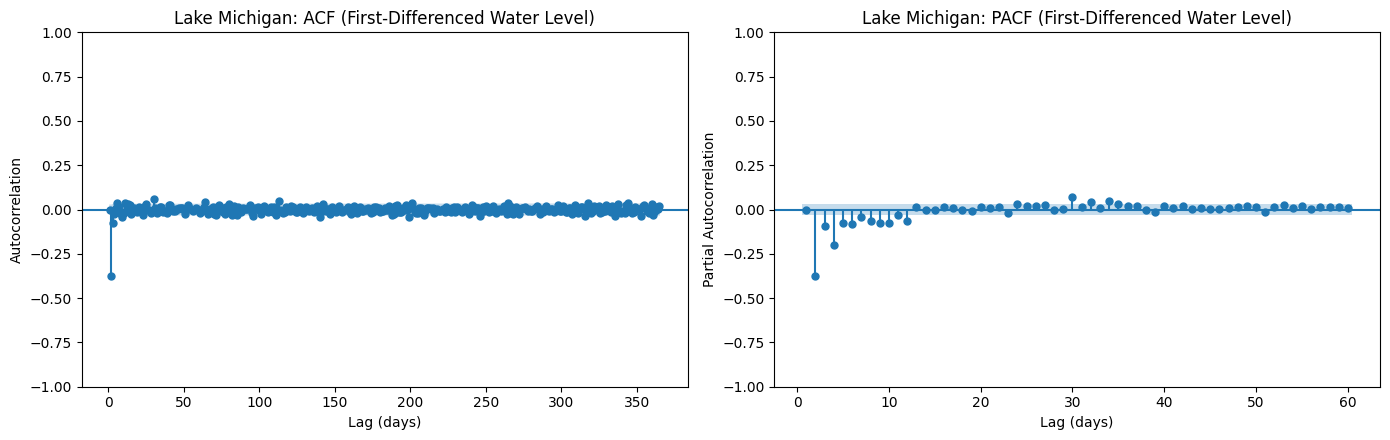

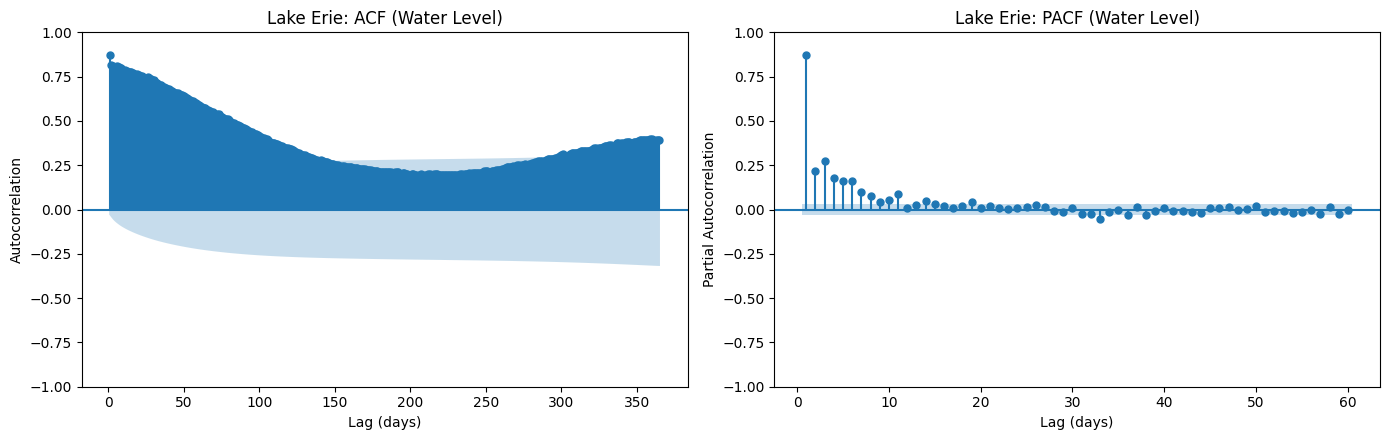

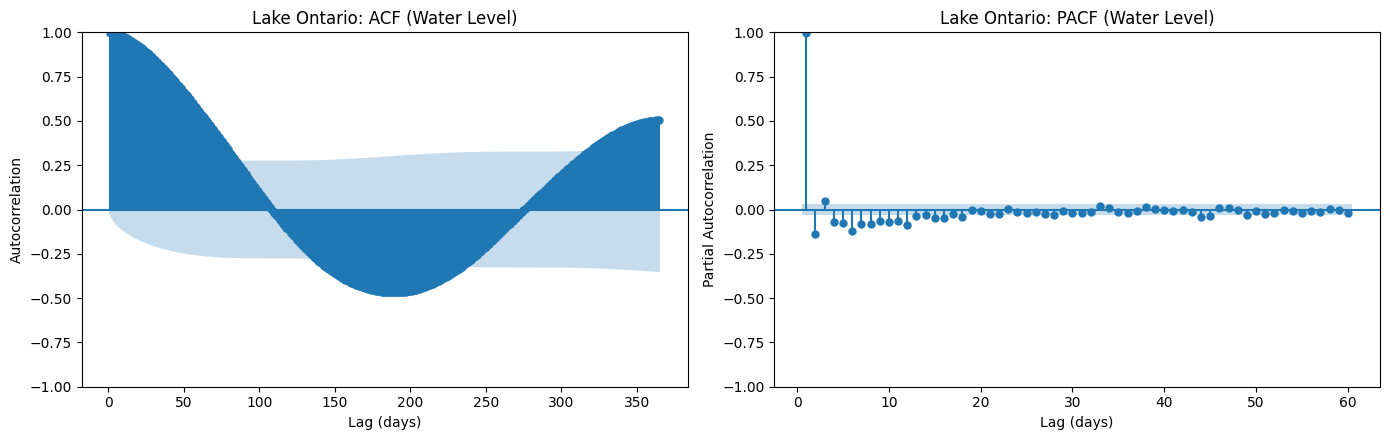

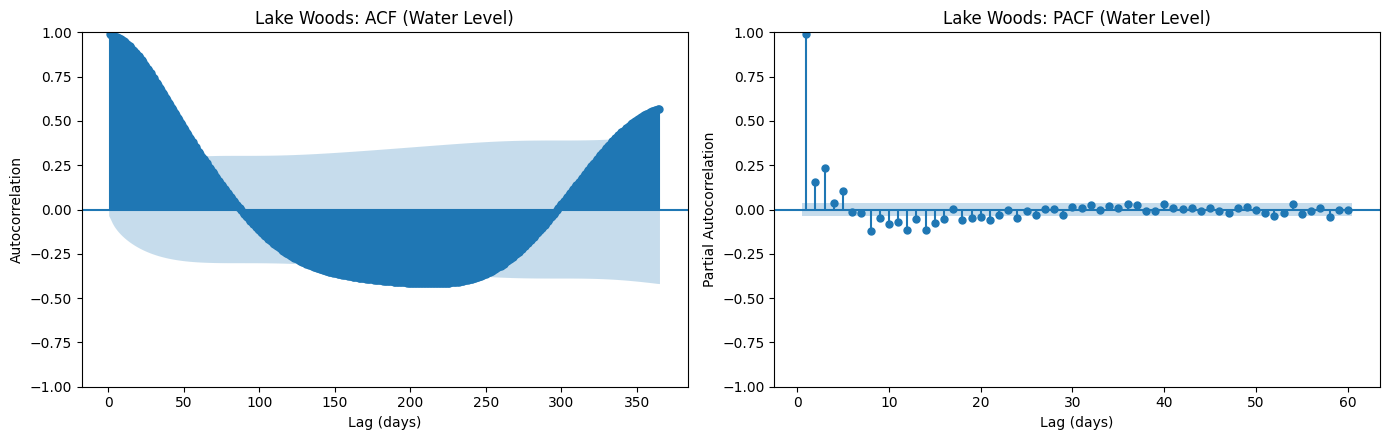

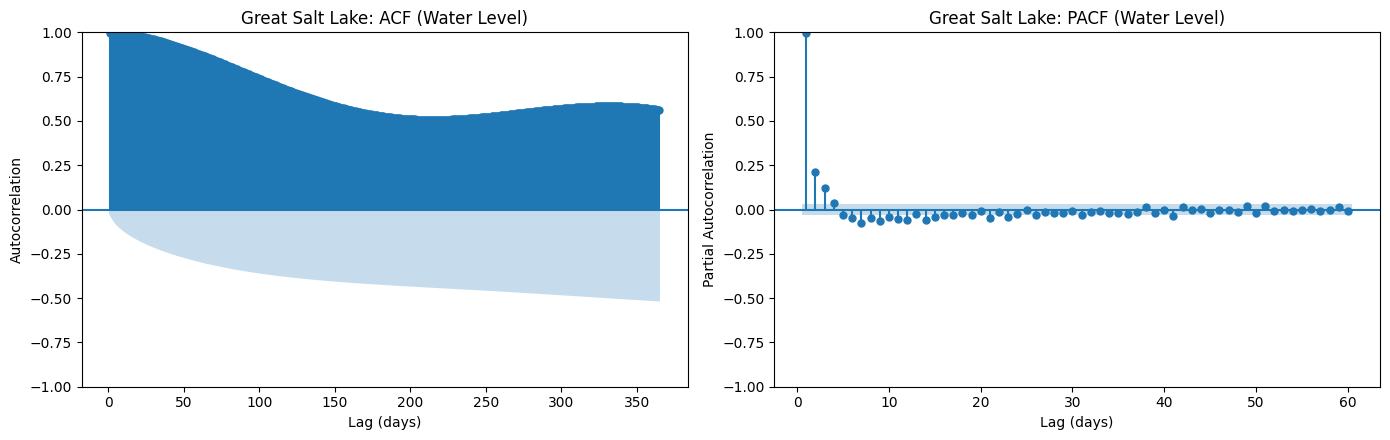

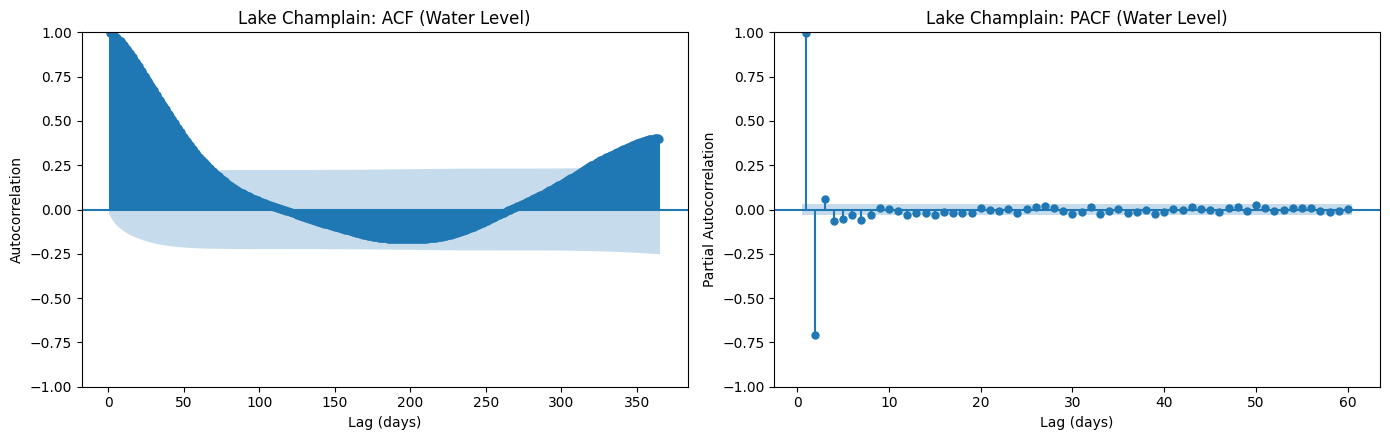

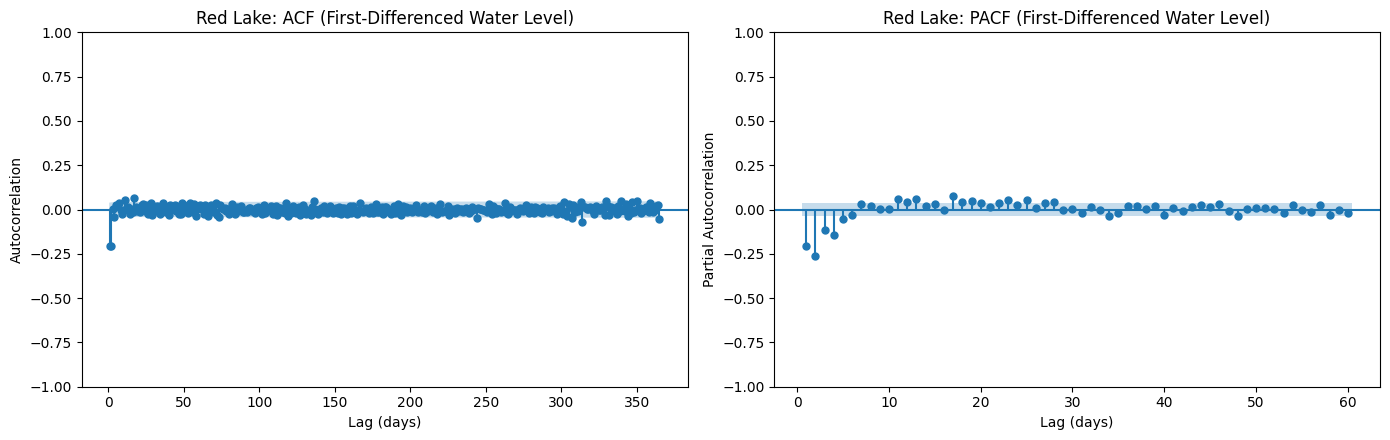

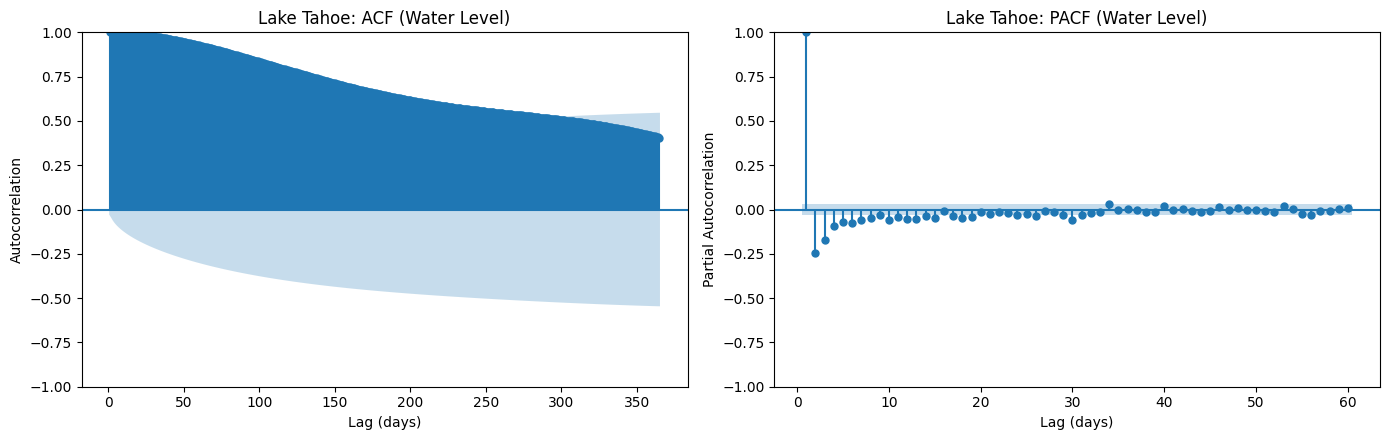

In [9]:
for lake in lake_order:

    d = int(
        adf_summary
        .loc[
            adf_summary["Lake"] == lake,
            "d"
        ]
        .iloc[0]
    )

    training_series = (
        lake_level_wide[lake]
        .loc[
            PARAMETER_TRAIN_START:
            PARAMETER_TRAIN_END
        ]
    )

    diagnostic_series = (
        longest_observed_segment(
            training_series
        )
    )

    if d == 1:
        diagnostic_series = (
            diagnostic_series
            .diff()
            .dropna()
        )
        representation = "First-Differenced Water Level"
    else:
        representation = "Water Level"

    acf_lags = min(
        365,
        max(1, len(diagnostic_series) // 2 - 1)
    )

    pacf_lags = min(
        60,
        max(1, len(diagnostic_series) // 2 - 1)
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 4.5)
    )

    plot_acf(
        diagnostic_series,
        lags=acf_lags,
        zero=False,
        ax=axes[0]
    )

    axes[0].set_title(
        f"{lake}: ACF ({representation})"
    )
    axes[0].set_xlabel("Lag (days)")
    axes[0].set_ylabel("Autocorrelation")

    plot_pacf(
        diagnostic_series,
        lags=pacf_lags,
        zero=False,
        method="ywm",
        ax=axes[1]
    )

    axes[1].set_title(
        f"{lake}: PACF ({representation})"
    )
    axes[1].set_xlabel("Lag (days)")
    axes[1].set_ylabel("Partial Autocorrelation")

    plt.tight_layout()
    plt.show()

## 3. Seasonal Naïve Baseline

### 3.1 Forecast-evaluation and seasonal-naïve utilities

In [10]:
def calculate_forecast_metrics(
    actual,
    predicted
):
    """Align by date and calculate RMSE, MAE and R-squared."""

    actual = (
        pd.Series(actual)
        .astype(float)
        .copy()
    )

    if isinstance(predicted, pd.Series):
        predicted = (
            predicted
            .astype(float)
            .copy()
        )
    else:
        predicted_array = np.asarray(
            predicted,
            dtype=float
        )

        if len(predicted_array) != len(actual):
            raise ValueError(
                "Actual and predicted values have different lengths."
            )

        predicted = pd.Series(
            predicted_array,
            index=actual.index,
            dtype=float
        )

    evaluation_data = pd.concat(
        [
            actual.rename("Actual"),
            predicted.rename("Predicted")
        ],
        axis=1
    ).dropna()

    if evaluation_data.empty:
        raise ValueError(
            "No aligned observations are available for evaluation."
        )

    if not np.isfinite(
        evaluation_data["Predicted"]
    ).all():
        raise FloatingPointError(
            "Forecast contains non-finite values."
        )

    observed_scale = max(
        1.0,
        np.abs(
            evaluation_data["Actual"]
        ).max()
    )

    if (
        np.abs(
            evaluation_data["Predicted"]
        ).max()
        > observed_scale * 100
    ):
        raise FloatingPointError(
            "Forecast is numerically explosive."
        )

    rmse = np.sqrt(
        mean_squared_error(
            evaluation_data["Actual"],
            evaluation_data["Predicted"]
        )
    )

    mae = mean_absolute_error(
        evaluation_data["Actual"],
        evaluation_data["Predicted"]
    )

    r2 = r2_score(
        evaluation_data["Actual"],
        evaluation_data["Predicted"]
    )

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "N": len(evaluation_data)
    }


def seasonal_naive_forecast(
    full_series,
    forecast_series,
    seasonal_lag=365
):
    """Fixed-origin recursive seasonal-naïve forecast using calendar-day lags."""

    full_series = (
        pd.Series(full_series)
        .astype(float)
        .sort_index()
        .asfreq("D")
    )

    forecast_index = (
        pd.DatetimeIndex(
            forecast_series.index
        )
        .sort_values()
    )

    if len(forecast_index) == 0:
        raise ValueError(
            "The forecast period is empty."
        )

    forecast_start = forecast_index.min()
    forecast_end = forecast_index.max()

    complete_forecast_index = pd.date_range(
        start=forecast_start,
        end=forecast_end,
        freq="D"
    )

    forecast = pd.Series(
        index=complete_forecast_index,
        dtype=float,
        name="Seasonal Naive Forecast"
    )

    for forecast_date in complete_forecast_index:

        source_date = (
            forecast_date
            - pd.Timedelta(days=seasonal_lag)
        )

        if source_date < forecast_start:
            prediction = full_series.get(
                source_date,
                np.nan
            )
        else:
            prediction = forecast.get(
                source_date,
                np.nan
            )

        forecast.loc[forecast_date] = prediction

    return forecast.reindex(
        forecast_index
    )

### 3.2 Lake Superior validation benchmark

Only the validation period is examined during model development. The 2022–2025 final test remains untouched until Section 8.

Lake Superior validation seasonal-naïve metrics:
{'RMSE': 0.5496957519465017, 'MAE': 0.4340419708029209, 'R2': -0.15471929848745236, 'N': 1096}


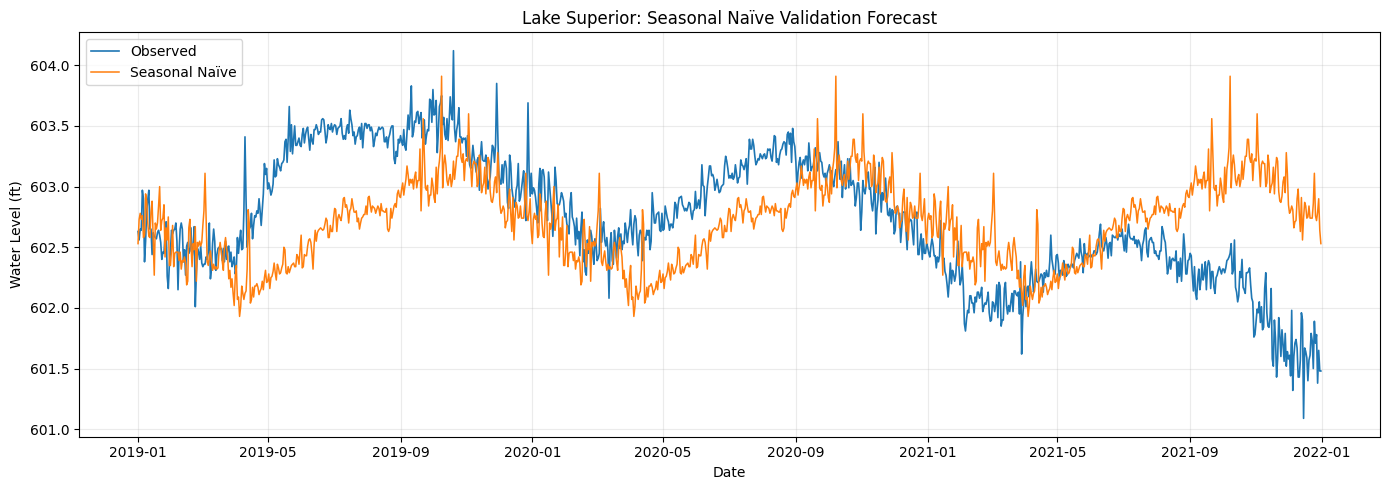

In [11]:
naive_validation_forecast = seasonal_naive_forecast(
    full_series=lake_series,
    forecast_series=validation,
    seasonal_lag=365
)

naive_validation_metrics = calculate_forecast_metrics(
    actual=validation,
    predicted=naive_validation_forecast
)

print("Lake Superior validation seasonal-naïve metrics:")
print(naive_validation_metrics)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    validation.index,
    validation,
    label="Observed",
    linewidth=1.2
)

ax.plot(
    naive_validation_forecast.index,
    naive_validation_forecast,
    label="Seasonal Naïve",
    linewidth=1.1
)

ax.set_title(
    "Lake Superior: Seasonal Naïve Validation Forecast"
)
ax.set_xlabel("Date")
ax.set_ylabel("Water Level (ft)")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 4. Annual SARIMA Feasibility Assessment

A direct daily SARIMA specification with an annual seasonal period of 365 days was previously tested on a reduced ten-year Lake Superior series. Optimisation remained incomplete after more than one hour and was manually interrupted. Because this assessment was intended only to evaluate computational feasibility and was not used for parameter selection or forecast evaluation, the expensive fitting step is disabled by default in this reproducibility notebook. Annual seasonality was subsequently represented using Fourier terms.

In [12]:
RUN_ANNUAL_SARIMA_FEASIBILITY = False

annual_sarima_feasibility_result = None

if RUN_ANNUAL_SARIMA_FEASIBILITY:

    feasibility_train = (
        parameter_train
        .loc["2006-01-01":"2015-12-31"]
        .copy()
    )

    if feasibility_train.isna().any():
        raise ValueError(
            "Lake Superior feasibility sample contains missing values."
        )

    annual_test_order = (1, 1, 0)
    annual_test_seasonal_order = (
        0,
        1,
        1,
        365
    )

    start_time = time.time()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        annual_model = SARIMAX(
            feasibility_train,
            order=annual_test_order,
            seasonal_order=annual_test_seasonal_order,
            trend=None,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        annual_fit = annual_model.fit(
            disp=False,
            maxiter=20
        )

    elapsed_seconds = (
        time.time() - start_time
    )

    annual_sarima_feasibility_result = {
        "Order": annual_test_order,
        "Seasonal Order": annual_test_seasonal_order,
        "N": len(feasibility_train),
        "Elapsed Seconds": elapsed_seconds,
        "Converged": annual_fit.mle_retvals.get(
            "converged",
            np.nan
        )
    }

    print(annual_sarima_feasibility_result)
else:
    print(
        "Annual SARIMA feasibility cell skipped. "
        "Set RUN_ANNUAL_SARIMA_FEASIBILITY=True to run it."
    )

Annual SARIMA feasibility cell skipped. Set RUN_ANNUAL_SARIMA_FEASIBILITY=True to run it.


## 5. Fourier-SARIMAX Model Development

Annual seasonality is represented with Fourier sine/cosine terms using a 365.25-day period. The ARIMA component represents short-term dependence. Candidate models are fitted on 2006-2018 and evaluated on 2019-2021.

### 5.1 Fourier terms and SARIMAX utilities

In [13]:
def create_fourier_terms(
    date_index,
    origin_date,
    period=365.25,
    fourier_order=2
):
    """Create annual Fourier sine and cosine terms for a daily DatetimeIndex."""

    date_index = pd.DatetimeIndex(
        date_index
    )

    elapsed_days = (
        date_index
        - pd.Timestamp(origin_date)
    ).days.astype(float)

    fourier_data = {}

    for k in range(1, fourier_order + 1):

        angle = (
            2
            * np.pi
            * k
            * elapsed_days
            / period
        )

        fourier_data[
            f"sin_{k}"
        ] = np.sin(angle)

        fourier_data[
            f"cos_{k}"
        ] = np.cos(angle)

    return pd.DataFrame(
        fourier_data,
        index=date_index
    )


def get_sarimax_trend(
    arima_order
):
    """Include a constant for d=0 level models, but not for d=1 models."""

    return (
        "c"
        if int(arima_order[1]) == 0
        else None
    )

In [14]:
fourier_origin = lake_level_wide.index.min()

example_fourier = create_fourier_terms(
    date_index=parameter_train.index,
    origin_date=fourier_origin,
    period=365.25,
    fourier_order=2
)

print("Fourier origin:", fourier_origin)
print("Example Fourier shape:", example_fourier.shape)
display(example_fourier.head())

Fourier origin: 2006-01-01 00:00:00
Example Fourier shape: (4748, 4)


,sin_1,cos_1,sin_2,cos_2
Date,,,,
2006-01-01,0.000000,1.000000,0.000000,1.000000
2006-01-02,0.017202,0.999852,0.034398,0.999408
2006-01-03,0.034398,0.999408,0.068755,0.997634
2006-01-04,0.051584,0.998669,0.103031,0.994678
2006-01-05,0.068755,0.997634,0.137185,0.990545


### 5.2 Candidate ARIMA and Fourier grid

For each lake, `d` is fixed by the training-period ADF test. Candidate `p` and `q` values range from 0 to 2, and Fourier order `K` ranges from 1 to 6. Models within 1% of the minimum validation RMSE are considered near-best; among those, the simpler specification is preferred.

In [15]:
CANDIDATE_P = range(0, 3)
CANDIDATE_Q = range(0, 3)
CANDIDATE_FOURIER_K = range(1, 7)


def fit_candidate_sarimax_with_fallback(
    model,
    primary_maxiter=200,
    fallback_maxiter=500
):
    """
    Fit a SARIMAX candidate using L-BFGS first.

    If L-BFGS does not converge, Powell is used as
    a fallback. If Powell converges, its parameters
    are used as starting values for an L-BFGS
    polishing attempt.

    The model specification itself is never changed.
    """

    lbfgs_error = None
    powell_error = None

   
    # 1. Primary optimiser: L-BFGS

    try:

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            lbfgs_fit = model.fit(
                method="lbfgs",
                disp=False,
                maxiter=primary_maxiter
            )

        lbfgs_converged = bool(
            lbfgs_fit.mle_retvals.get(
                "converged",
                False
            )
        )

        if lbfgs_converged:
            return (
                lbfgs_fit,
                "lbfgs"
            )

        lbfgs_error = (
            "L-BFGS did not converge."
        )

    except Exception as error:

        lbfgs_error = (
            f"L-BFGS failed: {error}"
        )


   # 2. Fallback optimiser: Powell

    try:

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            powell_fit = model.fit(
                method="powell",
                disp=False,
                maxiter=fallback_maxiter
            )

        powell_converged = bool(
            powell_fit.mle_retvals.get(
                "converged",
                False
            )
        )

        if not powell_converged:

            powell_error = (
                "Powell did not converge."
            )

            raise RuntimeError(
                powell_error
            )

    except Exception as error:

        if powell_error is None:
            powell_error = (
                f"Powell failed: {error}"
            )

        raise RuntimeError(
            f"{lbfgs_error} "
            f"{powell_error}"
        )


   # 3. L-BFGS polishing from the Powell solution

    try:

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            polished_fit = model.fit(
                start_params=powell_fit.params,
                method="lbfgs",
                disp=False,
                maxiter=fallback_maxiter
            )

        polished_converged = bool(
            polished_fit.mle_retvals.get(
                "converged",
                False
            )
        )

        if polished_converged:

            return (
                polished_fit,
                "powell_then_lbfgs"
            )

    except Exception:
        pass


    # Powell is retained if it converged but the
    # polishing attempt did not.
    return (
        powell_fit,
        "powell"
    )



def select_lake_fourier_sarimax(
    lake_name,
    maxiter=200
):
    """
    Select ARIMA(p,d,q) + Fourier(K) using
    parameter-training and validation data only.
    """

    lake_series_local = (
        lake_level_wide[lake_name]
        .astype(float)
        .sort_index()
        .asfreq("D")
    )

    train_local = lake_series_local.loc[
        PARAMETER_TRAIN_START:
        PARAMETER_TRAIN_END
    ]

    validation_local = lake_series_local.loc[
        VALIDATION_START:
        VALIDATION_END
    ]

    d = int(
        adf_summary
        .loc[
            adf_summary["Lake"] == lake_name,
            "d"
        ]
        .iloc[0]
    )

    candidate_orders = [
        (p, d, q)
        for p in CANDIDATE_P
        for q in CANDIDATE_Q
    ]

    results = []

    for arima_order, K in product(
        candidate_orders,
        CANDIDATE_FOURIER_K
    ):

        train_fourier = create_fourier_terms(
            date_index=train_local.index,
            origin_date=fourier_origin,
            period=365.25,
            fourier_order=K
        )

        validation_fourier = create_fourier_terms(
            date_index=validation_local.index,
            origin_date=fourier_origin,
            period=365.25,
            fourier_order=K
        )

        start_time = time.time()

        try:

            model = SARIMAX(
                endog=train_local,
                exog=train_fourier,
                order=arima_order,
                seasonal_order=(
                    0,
                    0,
                    0,
                    0
                ),
                trend=get_sarimax_trend(
                    arima_order
                ),
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fit, optimiser_used = (
                fit_candidate_sarimax_with_fallback(
                    model=model,
                    primary_maxiter=maxiter,
                    fallback_maxiter=500
                )
            )

            forecast_result = (
                fit.get_forecast(
                    steps=len(
                        validation_local
                    ),
                    exog=validation_fourier
                )
            )

            validation_forecast = pd.Series(
                forecast_result
                .predicted_mean
                .to_numpy(),
                index=validation_local.index,
                name="Forecast"
            )

            metrics = (
                calculate_forecast_metrics(
                    actual=validation_local,
                    predicted=validation_forecast
                )
            )

            status = "Success"
            error_message = None

        except Exception as error:

            metrics = {
                "RMSE": np.nan,
                "MAE": np.nan,
                "R2": np.nan,
                "N": 0
            }

            optimiser_used = None
            status = "Failed"
            error_message = str(
                error
            )

        results.append({
            "Lake":
                lake_name,

            "Order":
                arima_order,

            "p":
                arima_order[0],

            "d":
                arima_order[1],

            "q":
                arima_order[2],

            "Fourier K":
                K,

            "Optimiser":
                optimiser_used,

            "Validation RMSE":
                metrics["RMSE"],

            "Validation MAE":
                metrics["MAE"],

            "Validation R2":
                metrics["R2"],

            "Validation N":
                metrics["N"],

            "Elapsed Seconds":
                time.time()
                - start_time,

            "Status":
                status,

            "Error":
                error_message
        })

    results_df = pd.DataFrame(
        results
    )

    successful = (
        results_df[
            results_df["Status"]
            == "Success"
        ]
        .dropna(
            subset=[
                "Validation RMSE"
            ]
        )
        .copy()
    )

    if successful.empty:

        raise RuntimeError(
            f"No successful Fourier-SARIMAX "
            f"model for {lake_name}."
        )

    minimum_rmse = (
        successful[
            "Validation RMSE"
        ]
        .min()
    )

    # Apply the 1% parsimony rule.
    near_best = (
        successful[
            successful[
                "Validation RMSE"
            ]
            <= minimum_rmse * 1.01
        ]
        .copy()
    )

    near_best[
        "ARIMA Complexity"
    ] = (
        near_best["p"]
        + near_best["q"]
    )

    near_best = (
        near_best
        .sort_values(
            by=[
                "Fourier K",
                "ARIMA Complexity",
                "p",
                "q",
                "Validation RMSE"
            ],
            ascending=[
                True,
                True,
                True,
                True,
                True
            ]
        )
    )

    selected = (
        near_best
        .iloc[0]
    )

    return {
        "Lake":
            lake_name,

        "d":
            d,

        "Best ARIMA":
            tuple(
                selected[
                    "Order"
                ]
            ),

        "Best Fourier K":
            int(
                selected[
                    "Fourier K"
                ]
            ),

        "Validation RMSE":
            float(
                selected[
                    "Validation RMSE"
                ]
            ),

        "Validation MAE":
            float(
                selected[
                    "Validation MAE"
                ]
            ),

        "Validation R2":
            float(
                selected[
                    "Validation R2"
                ]
            ),

        "Validation N":
            int(
                selected[
                    "Validation N"
                ]
            ),

        "Minimum RMSE":
            float(
                minimum_rmse
            ),

        "Selected Optimiser":
            selected[
                "Optimiser"
            ],

        "Candidate Results":
            results_df
    }

## 6. Cross-Lake Fourier-SARIMAX Selection

In [16]:
all_fourier_selection_results = []
fourier_candidate_tables = []

for lake_name in lake_order:

    print(f"Selecting Fourier-SARIMAX for: {lake_name}")

    result = select_lake_fourier_sarimax(
        lake_name
    )

    all_fourier_selection_results.append(
        result
    )

    fourier_candidate_tables.append(
        result["Candidate Results"]
    )

fourier_selection_summary = pd.DataFrame(
    [
        {
            "Lake": result["Lake"],
            "ADF d": result["d"],
            "Best ARIMA": result["Best ARIMA"],
            "Best Fourier K": result["Best Fourier K"],
            "Validation RMSE": result["Validation RMSE"],
            "Validation MAE": result["Validation MAE"],
            "Validation R2": result["Validation R2"],
            "Validation N": result["Validation N"],
            "Minimum RMSE": result["Minimum RMSE"]
        }
        for result in all_fourier_selection_results
    ]
)

fourier_candidate_grid_all_lakes = pd.concat(
    fourier_candidate_tables,
    ignore_index=True
)

display(fourier_selection_summary)

Selecting Fourier-SARIMAX for: Lake Superior
Selecting Fourier-SARIMAX for: Lake Huron
Selecting Fourier-SARIMAX for: Lake Michigan
Selecting Fourier-SARIMAX for: Lake Erie
Selecting Fourier-SARIMAX for: Lake Ontario
Selecting Fourier-SARIMAX for: Lake Woods
Selecting Fourier-SARIMAX for: Great Salt Lake
Selecting Fourier-SARIMAX for: Lake Champlain
Selecting Fourier-SARIMAX for: Red Lake
Selecting Fourier-SARIMAX for: Lake Tahoe


,Lake,ADF d,Best ARIMA,Best Fourier K,Validation RMSE,Validation MAE,Validation R2,Validation N,Minimum RMSE
0,Lake Superior,1,"(0, 1, 0)",2,0.474723,0.352465,0.138783,1096,0.473892
1,Lake Huron,1,"(0, 1, 1)",1,0.888733,0.758776,-0.590961,1066,0.883998
2,Lake Michigan,1,"(0, 1, 0)",1,0.725663,0.644707,-0.038129,1096,0.725663
3,Lake Erie,0,"(1, 0, 1)",1,1.828323,1.733554,-6.896939,1096,1.811845
4,Lake Ontario,0,"(2, 0, 1)",1,0.926732,0.737108,0.341323,1096,0.926732
5,Lake Woods,0,"(2, 0, 0)",2,0.780917,0.612573,-0.108050,1096,0.774426
6,Great Salt Lake,0,"(1, 0, 2)",1,1.100383,0.912402,0.245806,1096,1.096379
7,Lake Champlain,0,"(2, 0, 1)",4,1.226458,1.074350,0.420128,1096,1.223548
8,Red Lake,1,"(0, 1, 0)",1,1.106115,0.944765,-0.645978,1096,1.103898
9,Lake Tahoe,0,"(2, 0, 1)",2,1.455801,1.115907,0.223769,1096,1.455801


### 6.1 Lake Superior prototype result

The Lake Superior row is displayed separately only for interpretation; it is generated by the same all-lake selection routine and is not hard-coded.

In [17]:
superior_fourier_selection = (
    fourier_selection_summary[
        fourier_selection_summary["Lake"]
        == "Lake Superior"
    ]
    .copy()
)

display(superior_fourier_selection)

,Lake,ADF d,Best ARIMA,Best Fourier K,Validation RMSE,Validation MAE,Validation R2,Validation N,Minimum RMSE
0,Lake Superior,1,"(0, 1, 0)",2,0.474723,0.352465,0.138783,1096,0.473892


In [18]:
fourier_optimizer_lookup = {
    result["Lake"]: result.get(
        "Selected Optimiser",
        None
    )
    for result in all_fourier_selection_results
}

fourier_selection_summary[
    "Selected Optimiser"
] = (
    fourier_selection_summary[
        "Lake"
    ].map(
        fourier_optimizer_lookup
    )
)

display(
    fourier_selection_summary[
        [
            "Lake",
            "Best ARIMA",
            "Best Fourier K",
            "Selected Optimiser",
            "Validation RMSE"
        ]
    ]
)

,Lake,Best ARIMA,Best Fourier K,Selected Optimiser,Validation RMSE
0,Lake Superior,"(0, 1, 0)",2,lbfgs,0.474723
1,Lake Huron,"(0, 1, 1)",1,lbfgs,0.888733
2,Lake Michigan,"(0, 1, 0)",1,lbfgs,0.725663
3,Lake Erie,"(1, 0, 1)",1,powell_then_lbfgs,1.828323
4,Lake Ontario,"(2, 0, 1)",1,lbfgs,0.926732
5,Lake Woods,"(2, 0, 0)",2,powell_then_lbfgs,0.780917
6,Great Salt Lake,"(1, 0, 2)",1,powell,1.100383
7,Lake Champlain,"(2, 0, 1)",4,lbfgs,1.226458
8,Red Lake,"(0, 1, 0)",1,lbfgs,1.106115
9,Lake Tahoe,"(2, 0, 1)",2,lbfgs,1.455801


## 7. Climate Predictor Assessment

### 7.1 Select forecasting-specific climate lags from the parameter-training period

In [19]:
def get_lake_climate_frame(
    lake_name
):
    """Return one lake's climate series on a complete daily index."""

    climate = (
        water_climate[
            water_climate["Lake"] == lake_name
        ]
        .copy()
        .set_index("Date")
        .sort_index()
        .asfreq("D")
    )

    return climate


def select_training_climate_lag(
    lake_name,
    climate_variable,
    max_lag=30
):
    """Select the strongest absolute training-period climate-water-level lag."""

    water_level = (
        lake_level_wide[lake_name]
        .loc[
            PARAMETER_TRAIN_START:
            PARAMETER_TRAIN_END
        ]
        .astype(float)
    )

    climate = get_lake_climate_frame(
        lake_name
    )

    climate_series = (
        climate[climate_variable]
        .loc[
            PARAMETER_TRAIN_START:
            PARAMETER_TRAIN_END
        ]
        .astype(float)
    )

    lag_results = []

    for lag in range(max_lag + 1):

        aligned = pd.concat(
            [
                water_level.rename("Water Level"),
                climate_series
                .shift(lag)
                .rename("Climate")
            ],
            axis=1
        ).dropna()

        if len(aligned) < 30:
            continue

        correlation = aligned[
            "Water Level"
        ].corr(
            aligned["Climate"]
        )

        lag_results.append({
            "Lake": lake_name,
            "Climate Variable": climate_variable,
            "Lag": lag,
            "Correlation": correlation,
            "Abs Correlation": abs(correlation),
            "N": len(aligned)
        })

    result_df = pd.DataFrame(
        lag_results
    )

    if result_df.empty:
        raise ValueError(
            f"No valid training CCF result for "
            f"{lake_name} - {climate_variable}."
        )

    result_df = result_df.sort_values(
        by=["Abs Correlation", "Lag"],
        ascending=[False, True]
    ).reset_index(drop=True)

    return result_df.iloc[0]

In [20]:
climate_lag_lookup = {}
training_ccf_lag_rows = []

for lake_name in lake_order:

    climate_lag_lookup[lake_name] = {}

    for climate_variable in [
        "PRCP",
        "TMEAN"
    ]:

        selected_lag = select_training_climate_lag(
            lake_name=lake_name,
            climate_variable=climate_variable,
            max_lag=30
        )

        lag_value = int(
            selected_lag["Lag"]
        )

        climate_lag_lookup[
            lake_name
        ][climate_variable] = lag_value

        training_ccf_lag_rows.append(
            selected_lag.to_dict()
        )

training_ccf_lag_summary = pd.DataFrame(
    training_ccf_lag_rows
)

display(training_ccf_lag_summary)
print()
print("Selected climate lags:")
print(climate_lag_lookup)

,Lake,Climate Variable,Lag,Correlation,Abs Correlation,N
0,Lake Superior,PRCP,29,0.083647,0.083647,4719
1,Lake Superior,TMEAN,29,0.354431,0.354431,4719
2,Lake Huron,PRCP,7,0.064671,0.064671,4741
3,Lake Huron,TMEAN,3,0.287694,0.287694,4745
4,Lake Michigan,PRCP,0,0.043505,0.043505,4748
5,Lake Michigan,TMEAN,0,0.302642,0.302642,4748
6,Lake Erie,PRCP,0,0.085766,0.085766,4748
7,Lake Erie,TMEAN,0,0.338834,0.338834,4748
8,Lake Ontario,PRCP,17,0.052235,0.052235,4731
9,Lake Ontario,TMEAN,0,0.473672,0.473672,4748



Selected climate lags:
{'Lake Superior': {'PRCP': 29, 'TMEAN': 29}, 'Lake Huron': {'PRCP': 7, 'TMEAN': 3}, 'Lake Michigan': {'PRCP': 0, 'TMEAN': 0}, 'Lake Erie': {'PRCP': 0, 'TMEAN': 0}, 'Lake Ontario': {'PRCP': 17, 'TMEAN': 0}, 'Lake Woods': {'PRCP': 29, 'TMEAN': 30}, 'Great Salt Lake': {'PRCP': 30, 'TMEAN': 30}, 'Lake Champlain': {'PRCP': 10, 'TMEAN': 30}, 'Red Lake': {'PRCP': 6, 'TMEAN': 0}, 'Lake Tahoe': {'PRCP': 0, 'TMEAN': 0}}


### 7.2 Build and validate exogenous predictor matrices

Fourier terms are always complete. Climate specifications are fitted only when their required exogenous series are complete over the relevant forecast period. Leading missing values created mechanically by lagging are trimmed from the beginning of the fitting sample; internal climate gaps are not silently interpolated or removed from the calendar.

In [21]:
def build_model_exog(
    lake_name,
    date_index,
    fourier_K,
    specification,
    lag_info
):
    """Build Fourier-only, contemporaneous-climate, or lagged-climate exog."""

    date_index = pd.DatetimeIndex(
        date_index
    )

    exog = create_fourier_terms(
        date_index=date_index,
        origin_date=fourier_origin,
        period=365.25,
        fourier_order=fourier_K
    )

    if specification == "Fourier-only":
        return exog

    climate = get_lake_climate_frame(
        lake_name
    )

    if specification == "Climate-contemporaneous":

        exog["PRCP"] = climate[
            "PRCP"
        ].reindex(date_index)

        exog["TMEAN"] = climate[
            "TMEAN"
        ].reindex(date_index)

        return exog

    if specification == "Climate-lagged":

        prcp_lag = int(
            lag_info["PRCP"]
        )

        tmean_lag = int(
            lag_info["TMEAN"]
        )

        exog[
            f"PRCP_lag_{prcp_lag}"
        ] = (
            climate["PRCP"]
            .shift(prcp_lag)
            .reindex(date_index)
        )

        exog[
            f"TMEAN_lag_{tmean_lag}"
        ] = (
            climate["TMEAN"]
            .shift(tmean_lag)
            .reindex(date_index)
        )

        return exog

    raise ValueError(
        f"Unknown specification: {specification}"
    )


def prepare_training_block(
    endog,
    exog,
    label
):
    """Trim leading exog gaps while rejecting internal exog missingness."""

    complete_exog = exog.notna().all(axis=1)

    if not complete_exog.any():
        raise ValueError(
            f"No complete exogenous observations: {label}"
        )

    first_valid_date = (
        complete_exog[
            complete_exog
        ]
        .index[0]
    )

    endog = endog.loc[
        first_valid_date:
    ]

    exog = exog.loc[
        first_valid_date:
    ]

    missing_exog = (
        exog
        .isna()
        .sum()
    )

    missing_exog = missing_exog[
        missing_exog > 0
    ]

    if not missing_exog.empty:
        raise ValueError(
            f"Internal missing exogenous values in {label}: "
            f"{missing_exog.to_dict()}"
        )

    return endog, exog


def require_complete_forecast_exog(
    exog,
    label
):
    """Reject missing exogenous values in a validation/test forecast horizon."""

    missing_exog = (
        exog
        .isna()
        .sum()
    )

    missing_exog = missing_exog[
        missing_exog > 0
    ]

    if not missing_exog.empty:
        raise ValueError(
            f"Missing forecast exogenous values in {label}: "
            f"{missing_exog.to_dict()}"
        )

### 7.3 Compare Fourier-only, contemporaneous-climate and lagged-climate specifications

All three specifications use the already selected ARIMA order and Fourier order. Selection is based on validation RMSE with the same 1% parsimony rule; when predictive performance is effectively tied, the simpler Fourier-only specification is preferred.

In [22]:
MODEL_COMPLEXITY_RANK = {
    "Fourier-only": 0,
    "Climate-contemporaneous": 1,
    "Climate-lagged": 2
}


def evaluate_validation_specification(
    lake_name,
    best_order,
    best_K,
    specification,
    lag_info,
    maxiter=200
):
    """
    Fit one locked temporal specification and
    evaluate it on the validation period.

    Exogenous-data checks are performed before
    optimisation. Retained climate gaps therefore
    remain genuine non-estimability conditions.

    For estimable models, L-BFGS is used first,
    followed by Powell fallback if required.
    """

     # 1. Water-level series

    lake_series_local = (
        lake_level_wide[lake_name]
        .astype(float)
        .sort_index()
        .asfreq("D")
    )

    train_endog = (
        lake_series_local.loc[
            PARAMETER_TRAIN_START:
            PARAMETER_TRAIN_END
        ]
        .copy()
    )

    validation_endog = (
        lake_series_local.loc[
            VALIDATION_START:
            VALIDATION_END
        ]
        .copy()
    )


    # 2. Construct exogenous variables

    train_exog = build_model_exog(
        lake_name=lake_name,
        date_index=train_endog.index,
        fourier_K=best_K,
        specification=specification,
        lag_info=lag_info
    )

    validation_exog = build_model_exog(
        lake_name=lake_name,
        date_index=validation_endog.index,
        fourier_K=best_K,
        specification=specification,
        lag_info=lag_info
    )


   # 3. Exogenous-data QC before optimisation

    train_endog, train_exog = (
        prepare_training_block(
            train_endog,
            train_exog,
            label=(
                f"{lake_name} - "
                f"{specification} training"
            )
        )
    )

    require_complete_forecast_exog(
        validation_exog,
        label=(
            f"{lake_name} - "
            f"{specification} validation"
        )
    )


    # 4. Build the locked SARIMAX specification

    model = SARIMAX(
        endog=train_endog,
        exog=train_exog,
        order=best_order,
        seasonal_order=(
            0,
            0,
            0,
            0
        ),
        trend=get_sarimax_trend(
            best_order
        ),
        enforce_stationarity=False,
        enforce_invertibility=False
    )


   
    # 5. Fit using optimiser fallback

    fit, optimiser_used = (
        fit_candidate_sarimax_with_fallback(
            model=model,
            primary_maxiter=maxiter,
            fallback_maxiter=500
        )
    )


   
    # 6. Validation forecast
    
    forecast_result = (
        fit.get_forecast(
            steps=len(
                validation_endog
            ),
            exog=validation_exog
        )
    )

    validation_forecast = pd.Series(
        forecast_result
        .predicted_mean
        .to_numpy(),
        index=validation_endog.index,
        name="Forecast"
    )


   
    # 7. Validation metrics
 
    metrics = (
        calculate_forecast_metrics(
            actual=validation_endog,
            predicted=validation_forecast
        )
    )


    return {
        "Lake":
            lake_name,

        "Model":
            specification,

        "Optimiser":
            optimiser_used,

        "Validation RMSE":
            metrics["RMSE"],

        "Validation MAE":
            metrics["MAE"],

        "Validation R2":
            metrics["R2"],

        "Validation N":
            metrics["N"],

        "Status":
            "Success",

        "Error":
            None
    }




In [23]:
def select_lake_climate_model(
    lake_name,
    best_order,
    best_K,
    lag_info
):
    """
    Compare the already selected Fourier-only baseline
    with contemporaneous- and lagged-climate extensions.

    The Fourier-only validation result is inherited from
    Section 5 rather than being refitted redundantly.
    """

    rows = []


   
    # 1. Retrieve the locked Fourier-only validation baseline from Section 5.


    fourier_row = (
        fourier_selection_summary[
            fourier_selection_summary[
                "Lake"
            ]
            == lake_name
        ]
        .iloc[0]
    )


    rows.append({
        "Lake":
            lake_name,

        "Model":
            "Fourier-only",

        "Optimiser":
            fourier_row.get(
                "Selected Optimiser",
                None
            ),

        "Validation RMSE":
            float(
                fourier_row[
                    "Validation RMSE"
                ]
            ),

        "Validation MAE":
            float(
                fourier_row[
                    "Validation MAE"
                ]
            ),

        "Validation R2":
            float(
                fourier_row[
                    "Validation R2"
                ]
            ),

        "Validation N":
            int(
                fourier_row[
                    "Validation N"
                ]
            ),

        "Status":
            "Success",

        "Error":
            None
    })


    # 2. Fit only the two climate-augmented specifications

    for specification in [
        "Climate-contemporaneous",
        "Climate-lagged"
    ]:

        try:

            row = (
                evaluate_validation_specification(
                    lake_name=lake_name,
                    best_order=best_order,
                    best_K=best_K,
                    specification=specification,
                    lag_info=lag_info
                )
            )

        except Exception as error:

            row = {
                "Lake":
                    lake_name,

                "Model":
                    specification,

                "Optimiser":
                    None,

                "Validation RMSE":
                    np.nan,

                "Validation MAE":
                    np.nan,

                "Validation R2":
                    np.nan,

                "Validation N":
                    0,

                "Status":
                    "Failed",

                "Error":
                    str(error)
            }

        rows.append(
            row
        )


    comparison = pd.DataFrame(
        rows
    )


     # 3. Retain successfully estimable specifications

    successful = (
        comparison[
            comparison[
                "Status"
            ]
            == "Success"
        ]
        .dropna(
            subset=[
                "Validation RMSE"
            ]
        )
        .copy()
    )


    # The Fourier-only baseline came directly from Section 5,
    # so this should never be empty.
    if successful.empty:

        raise RuntimeError(
            f"No valid validation "
            f"specification for {lake_name}."
        )


    # 4. Identify minimum validation RMSE

    minimum_rmse = (
        successful[
            "Validation RMSE"
        ]
        .min()
    )


     # 5. Apply the 1% parsimony rule

    near_best = (
        successful[
            successful[
                "Validation RMSE"
            ]
            <= minimum_rmse * 1.01
        ]
        .copy()
    )


    near_best[
        "Complexity Rank"
    ] = (
        near_best[
            "Model"
        ]
        .map(
            MODEL_COMPLEXITY_RANK
        )
    )


    near_best = (
        near_best
        .sort_values(
            by=[
                "Complexity Rank",
                "Validation RMSE"
            ],
            ascending=[
                True,
                True
            ]
        )
    )


    selected = (
        near_best
        .iloc[0]
    )


    return {
        "Lake":
            lake_name,

        "Best ARIMA":
            best_order,

        "Best Fourier K":
            int(
                best_K
            ),

        "Preferred Model":
            selected[
                "Model"
            ],

        "Selected Optimiser":
            selected[
                "Optimiser"
            ],

        "Validation RMSE":
            float(
                selected[
                    "Validation RMSE"
                ]
            ),

        "Validation MAE":
            float(
                selected[
                    "Validation MAE"
                ]
            ),

        "Validation R2":
            float(
                selected[
                    "Validation R2"
                ]
            ),

        "Validation N":
            int(
                selected[
                    "Validation N"
                ]
            ),

        "Minimum Validation RMSE":
            float(
                minimum_rmse
            ),

        "Candidate Comparison":
            comparison
    }

In [24]:
# Run climate-model assessment across all ten lakes

climate_selection_results = []
climate_candidate_tables = []


for _, row in fourier_selection_summary.iterrows():

    lake_name = row["Lake"]

    print(
        f"Assessing climate predictors for: "
        f"{lake_name}"
    )


    result = select_lake_climate_model(
        lake_name=lake_name,
        best_order=tuple(
            row["Best ARIMA"]
        ),
        best_K=int(
            row["Best Fourier K"]
        ),
        lag_info=climate_lag_lookup[
            lake_name
        ]
    )


    climate_selection_results.append(
        result
    )


   
    # Retain candidate-level validation results


    candidate_table = (
        result[
            "Candidate Comparison"
        ]
        .copy()
    )


    candidate_table[
        "Best ARIMA"
    ] = [
        result[
            "Best ARIMA"
        ]
    ] * len(
        candidate_table
    )


    candidate_table[
        "Best Fourier K"
    ] = (
        result[
            "Best Fourier K"
        ]
    )


    climate_candidate_tables.append(
        candidate_table
    )


# Cross-lake summary of selected validation models

all_lake_model_selection = pd.DataFrame(
    [
        {
            "Lake":
                result[
                    "Lake"
                ],

            "Best ARIMA":
                result[
                    "Best ARIMA"
                ],

            "Best Fourier K":
                result[
                    "Best Fourier K"
                ],

            "Preferred Model":
                result[
                    "Preferred Model"
                ],

            "Selected Optimiser":
                result[
                    "Selected Optimiser"
                ],

            "Validation RMSE":
                result[
                    "Validation RMSE"
                ],

            "Validation MAE":
                result[
                    "Validation MAE"
                ],

            "Validation R2":
                result[
                    "Validation R2"
                ],

            "Validation N":
                result[
                    "Validation N"
                ],

            "Minimum Validation RMSE":
                result[
                    "Minimum Validation RMSE"
                ]
        }

        for result
        in climate_selection_results
    ]
)


# Candidate-level validation results for all ten lakes

climate_candidate_validation_all_lakes = (
    pd.concat(
        climate_candidate_tables,
        ignore_index=True
    )
)


display(
    all_lake_model_selection
)

Assessing climate predictors for: Lake Superior
Assessing climate predictors for: Lake Huron
Assessing climate predictors for: Lake Michigan
Assessing climate predictors for: Lake Erie
Assessing climate predictors for: Lake Ontario
Assessing climate predictors for: Lake Woods
Assessing climate predictors for: Great Salt Lake
Assessing climate predictors for: Lake Champlain
Assessing climate predictors for: Red Lake
Assessing climate predictors for: Lake Tahoe


,Lake,Best ARIMA,Best Fourier K,Preferred Model,Selected Optimiser,Validation RMSE,Validation MAE,Validation R2,Validation N,Minimum Validation RMSE
0,Lake Superior,"(0, 1, 0)",2,Fourier-only,lbfgs,0.474723,0.352465,0.138783,1096,0.473802
1,Lake Huron,"(0, 1, 1)",1,Fourier-only,lbfgs,0.888733,0.758776,-0.590961,1066,0.888733
2,Lake Michigan,"(0, 1, 0)",1,Fourier-only,lbfgs,0.725663,0.644707,-0.038129,1096,0.725663
3,Lake Erie,"(1, 0, 1)",1,Fourier-only,powell_then_lbfgs,1.828323,1.733554,-6.896939,1096,1.828323
4,Lake Ontario,"(2, 0, 1)",1,Fourier-only,lbfgs,0.926732,0.737108,0.341323,1096,0.926732
5,Lake Woods,"(2, 0, 0)",2,Fourier-only,powell_then_lbfgs,0.780917,0.612573,-0.108050,1096,0.780917
6,Great Salt Lake,"(1, 0, 2)",1,Fourier-only,powell,1.100383,0.912402,0.245806,1096,1.100383
7,Lake Champlain,"(2, 0, 1)",4,Fourier-only,lbfgs,1.226458,1.074350,0.420128,1096,1.226458
8,Red Lake,"(0, 1, 0)",1,Fourier-only,lbfgs,1.106115,0.944765,-0.645978,1096,1.106115
9,Lake Tahoe,"(2, 0, 1)",2,Fourier-only,lbfgs,1.455801,1.115907,0.223769,1096,1.455801


In [25]:
lake_woods_climate_comparison = (
    climate_candidate_validation_all_lakes[
        climate_candidate_validation_all_lakes["Lake"]
        == "Lake Woods"
    ]
    .copy()
)

display(lake_woods_climate_comparison)

,Lake,Model,Optimiser,Validation RMSE,Validation MAE,Validation R2,Validation N,Status,Error,Best ARIMA,Best Fourier K
15,Lake Woods,Fourier-only,powell_then_lbfgs,0.780917,0.612573,-0.10805,1096,Success,None,"(2, 0, 0)",2
16,Lake Woods,Climate-contemporaneous,None,NaN,NaN,NaN,0,Failed,Internal missing exogenous values in Lake Wood...,"(2, 0, 0)",2
17,Lake Woods,Climate-lagged,None,NaN,NaN,NaN,0,Failed,Internal missing exogenous values in Lake Wood...,"(2, 0, 0)",2


In [26]:
display(
    climate_candidate_validation_all_lakes
)

,Lake,Model,Optimiser,Validation RMSE,Validation MAE,Validation R2,Validation N,Status,Error,Best ARIMA,Best Fourier K
0,Lake Superior,Fourier-only,lbfgs,0.474723,0.352465,0.138783,1096,Success,None,"(0, 1, 0)",2
1,Lake Superior,Climate-contemporaneous,lbfgs,0.478010,0.351165,0.126816,1096,Success,None,"(0, 1, 0)",2
2,Lake Superior,Climate-lagged,lbfgs,0.473802,0.352185,0.142124,1096,Success,None,"(0, 1, 0)",2
3,Lake Huron,Fourier-only,lbfgs,0.888733,0.758776,-0.590961,1066,Success,None,"(0, 1, 1)",1
4,Lake Huron,Climate-contemporaneous,None,NaN,NaN,NaN,0,Failed,Internal missing exogenous values in Lake Huro...,"(0, 1, 1)",1
5,Lake Huron,Climate-lagged,None,NaN,NaN,NaN,0,Failed,Missing forecast exogenous values in Lake Huro...,"(0, 1, 1)",1
6,Lake Michigan,Fourier-only,lbfgs,0.725663,0.644707,-0.038129,1096,Success,None,"(0, 1, 0)",1
7,Lake Michigan,Climate-contemporaneous,lbfgs,0.737868,0.652807,-0.073343,1096,Success,None,"(0, 1, 0)",1
8,Lake Michigan,Climate-lagged,lbfgs,0.737868,0.652807,-0.073343,1096,Success,None,"(0, 1, 0)",1
9,Lake Erie,Fourier-only,powell_then_lbfgs,1.828323,1.733554,-6.896939,1096,Success,None,"(1, 0, 1)",1


### 7.4 WESD availability assessment

WESD is not included in the main cross-lake forecasting comparison because its temporal coverage is inconsistent. The following audit records availability without interpolating WESD or using it for model selection.

In [27]:
if "WESD" in water_climate.columns:

    wesd_yearly_coverage = (
        water_climate
        .assign(
            Year=water_climate["Date"].dt.year,
            WESD_Available=water_climate["WESD"].notna()
        )
        .groupby(
            ["Lake", "Year"],
            as_index=False
        )
        .agg(
            Available_WESD_Days=(
                "WESD_Available",
                "sum"
            ),
            Total_Days=(
                "WESD_Available",
                "size"
            )
        )
    )

    wesd_yearly_coverage[
        "Coverage Proportion"
    ] = (
        wesd_yearly_coverage[
            "Available_WESD_Days"
        ]
        / wesd_yearly_coverage[
            "Total_Days"
        ]
    )

    wesd_lake_summary = (
        water_climate
        .groupby("Lake", as_index=False)
        .agg(
            Available_WESD_Days=(
                "WESD",
                "count"
            ),
            Total_Days=(
                "WESD",
                "size"
            )
        )
    )

    wesd_lake_summary[
        "Coverage Proportion"
    ] = (
        wesd_lake_summary[
            "Available_WESD_Days"
        ]
        / wesd_lake_summary[
            "Total_Days"
        ]
    )

    display(wesd_lake_summary)
    display(wesd_yearly_coverage)

else:
    wesd_lake_summary = pd.DataFrame()
    wesd_yearly_coverage = pd.DataFrame()

    print(
        "WESD is not present in the forecasting input file."
    )

,Lake,Available_WESD_Days,Total_Days,Coverage Proportion
0,Great Salt Lake,1826,7305,0.249966
1,Lake Champlain,1826,7305,0.249966
2,Lake Erie,2138,7305,0.292676
3,Lake Huron,0,7305,0.000000
4,Lake Michigan,1826,7305,0.249966
5,Lake Ontario,1861,7305,0.254757
6,Lake Superior,1826,7305,0.249966
7,Lake Tahoe,7305,7305,1.000000
8,Lake Woods,0,7305,0.000000
9,Red Lake,0,7305,0.000000


,Lake,Year,Available_WESD_Days,Total_Days,Coverage Proportion
0,Great Salt Lake,2006,365,365,1.0
1,Great Salt Lake,2007,365,365,1.0
2,Great Salt Lake,2008,366,366,1.0
3,Great Salt Lake,2009,365,365,1.0
4,Great Salt Lake,2010,365,365,1.0
...,...,...,...,...,...
195,Red Lake,2021,0,365,0.0
196,Red Lake,2022,0,365,0.0
197,Red Lake,2023,0,365,0.0
198,Red Lake,2024,0,366,0.0


## 8. Final Out-of-Sample Evaluation

Only after all temporal and climate specifications have been selected on the validation period are the models refitted on 2006–2021 and evaluated once on the untouched 2022–2025 final test period. Missing water-level observations remain on the daily calendar; they are excluded only when evaluation metrics are calculated.

### 8.1 Final refit and forecast function

In [28]:
def fit_final_sarimax_with_fallback(
    model,
    maxiter=500
):
    """
    Fit a locked SARIMAX specification.

    L-BFGS is used as the primary optimiser.
    If it does not converge, Powell is used as
    a fallback. If Powell converges, its parameter
    estimates are used as starting values for a final
    L-BFGS polishing attempt.

    No model specification is changed by this procedure.
    """

 
    # 1. Primary optimiser: L-BFGS
    

    with warnings.catch_warnings():

        warnings.simplefilter(
            "ignore"
        )

        lbfgs_fit = model.fit(
            method="lbfgs",
            disp=False,
            maxiter=maxiter
        )

    lbfgs_converged = bool(
        lbfgs_fit.mle_retvals.get(
            "converged",
            False
        )
    )

    if lbfgs_converged:

        return (
            lbfgs_fit,
            "lbfgs"
        )


   
    # 2. Fallback optimiser: Powell
    

    with warnings.catch_warnings():

        warnings.simplefilter(
            "ignore"
        )

        powell_fit = model.fit(
            method="powell",
            disp=False,
            maxiter=maxiter
        )

    powell_converged = bool(
        powell_fit.mle_retvals.get(
            "converged",
            False
        )
    )

    if not powell_converged:

        raise RuntimeError(
            "Neither L-BFGS nor Powell converged."
        )


    
    # 3. L-BFGS polishing from Powell parameters 

    try:

        with warnings.catch_warnings():

            warnings.simplefilter(
                "ignore"
            )

            polished_fit = model.fit(
                start_params=(
                    powell_fit.params
                ),
                method="lbfgs",
                disp=False,
                maxiter=maxiter
            )

        polished_converged = bool(
            polished_fit.mle_retvals.get(
                "converged",
                False
            )
        )

        if polished_converged:

            return (
                polished_fit,
                "powell_then_lbfgs"
            )

    except Exception:
        pass


    # Powell solution is retained if it converged
    # but the L-BFGS polishing step did not.
    return (
        powell_fit,
        "powell"
    )



def calculate_common_model_naive_metrics(
    actual,
    model_forecast,
    naive_forecast
):
    """
    Calculate final-model and seasonal-naive metrics
    on their respective available observed dates.

    Common-date metrics are retained separately for
    direct model-versus-baseline comparison.
    """

    evaluation_data = pd.concat(
        [
            pd.Series(
                actual
            ).rename(
                "Actual"
            ),

            pd.Series(
                model_forecast
            ).rename(
                "Model Forecast"
            ),

            pd.Series(
                naive_forecast
            ).rename(
                "Seasonal Naive"
            )
        ],
        axis=1
    )


    # ---------------------------------------------------------
    # 1. Final-model metrics
    # ---------------------------------------------------------

    model_data = (
        evaluation_data[
            [
                "Actual",
                "Model Forecast"
            ]
        ]
        .dropna()
    )

    if model_data.empty:

        raise ValueError(
            "No observations are available "
            "for final-model evaluation."
        )

    model_metrics = (
        calculate_forecast_metrics(
            actual=model_data[
                "Actual"
            ],
            predicted=model_data[
                "Model Forecast"
            ]
        )
    )

    model_observed_sd = (
        model_data[
            "Actual"
        ]
        .std()
    )

    model_metrics[
        "NRMSE"
    ] = (
        model_metrics[
            "RMSE"
        ]
        / model_observed_sd
        if (
            pd.notna(
                model_observed_sd
            )
            and model_observed_sd > 0
        )
        else np.nan
    )


    # ---------------------------------------------------------
    # 2. Seasonal-naive metrics
    # ---------------------------------------------------------

    naive_data = (
        evaluation_data[
            [
                "Actual",
                "Seasonal Naive"
            ]
        ]
        .dropna()
    )

    if naive_data.empty:

        raise ValueError(
            "No observations are available "
            "for seasonal-naive evaluation."
        )

    naive_metrics = (
        calculate_forecast_metrics(
            actual=naive_data[
                "Actual"
            ],
            predicted=naive_data[
                "Seasonal Naive"
            ]
        )
    )

    naive_observed_sd = (
        naive_data[
            "Actual"
        ]
        .std()
    )

    naive_metrics[
        "NRMSE"
    ] = (
        naive_metrics[
            "RMSE"
        ]
        / naive_observed_sd
        if (
            pd.notna(
                naive_observed_sd
            )
            and naive_observed_sd > 0
        )
        else np.nan
    )


    # ---------------------------------------------------------
    # 3. Common-date metrics
    # ---------------------------------------------------------

    common_data = (
        evaluation_data
        .dropna()
    )

    if common_data.empty:

        raise ValueError(
            "No common evaluation dates are available "
            "for model-versus-baseline comparison."
        )

    common_model_metrics = (
        calculate_forecast_metrics(
            actual=common_data[
                "Actual"
            ],
            predicted=common_data[
                "Model Forecast"
            ]
        )
    )

    common_naive_metrics = (
        calculate_forecast_metrics(
            actual=common_data[
                "Actual"
            ],
            predicted=common_data[
                "Seasonal Naive"
            ]
        )
    )


    return (
        model_metrics,
        naive_metrics,
        common_model_metrics,
        common_naive_metrics,
        evaluation_data,
        common_data
    )



def evaluate_final_lake_model(
    lake_name,
    best_order,
    best_K,
    preferred_model,
    lag_info,
    maxiter=500
):
    """
    Refit the locked model specification on 2006–2021
    and evaluate it on the independent 2022–2025
    final-test period.
    """

    lake_series_local = (
        lake_level_wide[
            lake_name
        ]
        .astype(float)
        .sort_index()
        .asfreq("D")
    )


    # ---------------------------------------------------------
    # 1. Final refit and test periods
    # ---------------------------------------------------------

    final_train_endog = (
        lake_series_local.loc[
            PARAMETER_TRAIN_START:
            VALIDATION_END
        ]
        .copy()
    )

    final_test_endog = (
        lake_series_local.loc[
            FINAL_TEST_START:
            FINAL_TEST_END
        ]
        .copy()
    )


    # ---------------------------------------------------------
    # 2. Construct final model exogenous variables
    # ---------------------------------------------------------

    final_train_exog = (
        build_model_exog(
            lake_name=lake_name,
            date_index=final_train_endog.index,
            fourier_K=best_K,
            specification=preferred_model,
            lag_info=lag_info
        )
    )

    final_test_exog = (
        build_model_exog(
            lake_name=lake_name,
            date_index=final_test_endog.index,
            fourier_K=best_K,
            specification=preferred_model,
            lag_info=lag_info
        )
    )


    # Preserve the daily calendar while removing only
    # unusable leading training rows caused by lagged exog.
    final_train_endog, final_train_exog = (
        prepare_training_block(
            final_train_endog,
            final_train_exog,
            label=(
                f"{lake_name} - final refit"
            )
        )
    )


    # Exogenous variables must be complete throughout
    # the forecast horizon.
    require_complete_forecast_exog(
        final_test_exog,
        label=(
            f"{lake_name} - final test"
        )
    )


    # ---------------------------------------------------------
    # 3. Build the locked final SARIMAX model
    # ---------------------------------------------------------

    final_model = SARIMAX(
        endog=final_train_endog,
        exog=final_train_exog,
        order=best_order,
        seasonal_order=(
            0,
            0,
            0,
            0
        ),
        trend=get_sarimax_trend(
            best_order
        ),
        enforce_stationarity=False,
        enforce_invertibility=False
    )


    # ---------------------------------------------------------
    # 4. Fit using optimiser fallback if required
    # ---------------------------------------------------------

    final_fit, optimiser_used = (
        fit_final_sarimax_with_fallback(
            model=final_model,
            maxiter=maxiter
        )
    )

    print(
        f"{lake_name}: final optimiser = "
        f"{optimiser_used}"
    )


    # ---------------------------------------------------------
    # 5. Generate final-test forecast
    # ---------------------------------------------------------

    forecast_result = (
        final_fit.get_forecast(
            steps=len(
                final_test_endog
            ),
            exog=final_test_exog
        )
    )

    final_forecast = pd.Series(
        forecast_result
        .predicted_mean
        .to_numpy(),
        index=final_test_endog.index,
        name="Forecast"
    )


    # ---------------------------------------------------------
    # 6. Seasonal-naive benchmark
    # ---------------------------------------------------------

    naive_forecast = (
        seasonal_naive_forecast(
            full_series=lake_series_local,
            forecast_series=final_test_endog,
            seasonal_lag=365
        )
    )


    # ---------------------------------------------------------
    # 7. Final evaluation
    # ---------------------------------------------------------

    (
        final_metrics,
        naive_metrics,
        common_model_metrics,
        common_naive_metrics,
        evaluation_data,
        common_evaluation_data
    ) = (
        calculate_common_model_naive_metrics(
            actual=final_test_endog,
            model_forecast=final_forecast,
            naive_forecast=naive_forecast
        )
    )


    # Percentage improvements must use exactly
    # the same common evaluation dates.
    if (
        common_naive_metrics[
            "RMSE"
        ]
        > 0
    ):

        rmse_improvement = (
            (
                common_naive_metrics[
                    "RMSE"
                ]
                - common_model_metrics[
                    "RMSE"
                ]
            )
            / common_naive_metrics[
                "RMSE"
            ]
            * 100
        )

    else:

        rmse_improvement = np.nan


    if (
        common_naive_metrics[
            "MAE"
        ]
        > 0
    ):

        mae_improvement = (
            (
                common_naive_metrics[
                    "MAE"
                ]
                - common_model_metrics[
                    "MAE"
                ]
            )
            / common_naive_metrics[
                "MAE"
            ]
            * 100
        )

    else:

        mae_improvement = np.nan


    # ---------------------------------------------------------
    # 8. Return results
    # ---------------------------------------------------------

    return {
        "Lake":
            lake_name,

        "Model":
            preferred_model,

        "Best ARIMA":
            best_order,

        "Best Fourier K":
            int(
                best_K
            ),

        "Final Optimiser":
            optimiser_used,

        # Main final-model performance
        "RMSE":
            final_metrics[
                "RMSE"
            ],

        "MAE":
            final_metrics[
                "MAE"
            ],

        "R2":
            final_metrics[
                "R2"
            ],

        "NRMSE":
            final_metrics[
                "NRMSE"
            ],

        "N_test":
            final_metrics[
                "N"
            ],

        # Seasonal-naive performance
        "Naive RMSE":
            naive_metrics[
                "RMSE"
            ],

        "Naive MAE":
            naive_metrics[
                "MAE"
            ],

        "Naive R2":
            naive_metrics[
                "R2"
            ],

        "Naive NRMSE":
            naive_metrics[
                "NRMSE"
            ],

        "Naive N_test":
            naive_metrics[
                "N"
            ],

        # Common-date comparison
        "Common N_test":
            common_model_metrics[
                "N"
            ],

        "Common Model RMSE":
            common_model_metrics[
                "RMSE"
            ],

        "Common Model MAE":
            common_model_metrics[
                "MAE"
            ],

        "Common Naive RMSE":
            common_naive_metrics[
                "RMSE"
            ],

        "Common Naive MAE":
            common_naive_metrics[
                "MAE"
            ],

        "RMSE Improvement (%)":
            rmse_improvement,

        "MAE Improvement (%)":
            mae_improvement,

        # Objects required later
        "Observed":
            final_test_endog,

        "Forecast":
            final_forecast,

        "Naive Forecast":
            naive_forecast,

        "Evaluation Data":
            evaluation_data,

        "Common Evaluation Data":
            common_evaluation_data,

        "Fitted Model":
            final_fit
    }

### 8.2 Run the final evaluation for all ten lakes

In [29]:
all_lake_final_results = []
final_evaluation_failures = []


for _, row in (
    all_lake_model_selection
    .iterrows()
):

    lake_name = row[
        "Lake"
    ]

    print(
        "\n"
        + "=" * 60
    )

    print(
        f"Final evaluation: "
        f"{lake_name}"
    )

    try:

        result = (
            evaluate_final_lake_model(
                lake_name=lake_name,
                best_order=tuple(
                    row[
                        "Best ARIMA"
                    ]
                ),
                best_K=int(
                    row[
                        "Best Fourier K"
                    ]
                ),
                preferred_model=row[
                    "Preferred Model"
                ],
                lag_info=climate_lag_lookup[
                    lake_name
                ],
                maxiter=500
            )
        )

        all_lake_final_results.append(
            result
        )

        print(
            f"Completed successfully: "
            f"{lake_name}"
        )

    except Exception as error:

        final_evaluation_failures.append({
            "Lake":
                lake_name,

            "Error Type":
                type(
                    error
                ).__name__,

            "Error":
                str(
                    error
                )
        })

        print(
            f"FAILED: "
            f"{lake_name}: "
            f"{error}"
        )


print(
    "\n"
    + "=" * 60
)

if final_evaluation_failures:

    print(
        "Final evaluation failures:"
    )

    display(
        pd.DataFrame(
            final_evaluation_failures
        )
    )

else:

    print(
        "All ten final evaluations "
        "completed successfully."
    )


Final evaluation: Lake Superior
Lake Superior: final optimiser = lbfgs
Completed successfully: Lake Superior

Final evaluation: Lake Huron
Lake Huron: final optimiser = lbfgs
Completed successfully: Lake Huron

Final evaluation: Lake Michigan
Lake Michigan: final optimiser = lbfgs
Completed successfully: Lake Michigan

Final evaluation: Lake Erie
Lake Erie: final optimiser = powell
Completed successfully: Lake Erie

Final evaluation: Lake Ontario
Lake Ontario: final optimiser = powell_then_lbfgs
Completed successfully: Lake Ontario

Final evaluation: Lake Woods
Lake Woods: final optimiser = powell_then_lbfgs
Completed successfully: Lake Woods

Final evaluation: Great Salt Lake
Great Salt Lake: final optimiser = powell
Completed successfully: Great Salt Lake

Final evaluation: Lake Champlain
Lake Champlain: final optimiser = lbfgs
Completed successfully: Lake Champlain

Final evaluation: Red Lake
Red Lake: final optimiser = lbfgs
Completed successfully: Red Lake

Final evaluation: Lake

In [30]:
cross_lake_final_summary = pd.DataFrame(
    [
        {
            "Lake":
                result[
                    "Lake"
                ],

            "Preferred Model":
                result[
                    "Model"
                ],

            "Best ARIMA":
                result[
                    "Best ARIMA"
                ],

            "Best Fourier K":
                result[
                    "Best Fourier K"
                ],

            "Final Optimiser":
                result[
                    "Final Optimiser"
                ],

            "RMSE":
                result[
                    "RMSE"
                ],

            "MAE":
                result[
                    "MAE"
                ],

            "R2":
                result[
                    "R2"
                ],

            "NRMSE":
                result[
                    "NRMSE"
                ],

            "N_test":
                result[
                    "N_test"
                ],

            "Seasonal Naive RMSE":
                result[
                    "Naive RMSE"
                ],

            "Seasonal Naive MAE":
                result[
                    "Naive MAE"
                ],

            "Seasonal Naive R2":
                result[
                    "Naive R2"
                ],

            "Seasonal Naive NRMSE":
                result[
                    "Naive NRMSE"
                ],

            "Naive N_test":
                result[
                    "Naive N_test"
                ],

            "Common N_test":
                result[
                    "Common N_test"
                ],

            "Common Model RMSE":
                result[
                    "Common Model RMSE"
                ],

            "Common Model MAE":
                result[
                    "Common Model MAE"
                ],

            "Common Naive RMSE":
                result[
                    "Common Naive RMSE"
                ],

            "Common Naive MAE":
                result[
                    "Common Naive MAE"
                ],

            "RMSE Improvement (%)":
                result[
                    "RMSE Improvement (%)"
                ],

            "MAE Improvement (%)":
                result[
                    "MAE Improvement (%)"
                ]
        }

        for result
        in all_lake_final_results
    ]
)


# Preserve the established lake order.
cross_lake_final_summary[
    "Lake"
] = pd.Categorical(
    cross_lake_final_summary[
        "Lake"
    ],
    categories=lake_order,
    ordered=True
)

cross_lake_final_summary = (
    cross_lake_final_summary
    .sort_values(
        "Lake"
    )
    .reset_index(
        drop=True
    )
)

cross_lake_final_summary[
    "Lake"
] = (
    cross_lake_final_summary[
        "Lake"
    ]
    .astype(str)
)


display(
    cross_lake_final_summary
)

,Lake,Preferred Model,Best ARIMA,Best Fourier K,Final Optimiser,RMSE,MAE,R2,NRMSE,N_test,...,Seasonal Naive R2,Seasonal Naive NRMSE,Naive N_test,Common N_test,Common Model RMSE,Common Model MAE,Common Naive RMSE,Common Naive MAE,RMSE Improvement (%),MAE Improvement (%)
0,Lake Superior,Fourier-only,"(0, 1, 0)",2,lbfgs,0.587633,0.463851,0.050600,0.974031,1430,...,-0.009923,1.004598,1430,1430,0.587633,0.463851,0.606074,0.488944,3.042695,5.132137
1,Lake Huron,Fourier-only,"(0, 1, 1)",1,lbfgs,1.037426,0.903401,-1.594157,1.610087,1461,...,-4.613020,2.368298,1341,1341,1.022446,0.885294,1.558199,1.421216,34.382796,37.708639
2,Lake Michigan,Fourier-only,"(0, 1, 0)",1,lbfgs,1.393306,1.289528,-3.161038,2.039164,1461,...,-4.168449,2.272644,1461,1461,1.393306,1.289528,1.552837,1.406277,10.273498,8.301956
3,Lake Erie,Fourier-only,"(1, 0, 1)",1,powell,0.575391,0.442992,0.282786,0.846595,1461,...,-1.836474,1.683607,1461,1461,0.575391,0.442992,1.144268,0.934579,49.715391,52.599867
4,Lake Ontario,Fourier-only,"(2, 0, 1)",1,powell_then_lbfgs,0.933800,0.849247,-0.169405,1.081012,1431,...,-0.464293,1.209657,1431,1431,0.933800,0.849247,1.044925,0.898840,10.634781,5.517463
5,Lake Woods,Fourier-only,"(2, 0, 0)",2,powell_then_lbfgs,1.063212,0.595948,0.297971,0.837585,1461,...,-0.217398,1.102980,1461,1461,1.063212,0.595948,1.400099,0.863193,24.061652,30.960057
6,Great Salt Lake,Fourier-only,"(1, 0, 2)",1,powell,2.962064,2.624971,-2.417383,1.847984,1461,...,-0.000537,0.999926,1461,1461,2.962064,2.624971,1.602744,1.450924,-84.812035,-80.917166
7,Lake Champlain,Fourier-only,"(2, 0, 1)",4,lbfgs,1.141995,0.960291,0.459474,0.734953,1461,...,-0.188979,1.090030,1461,1461,1.141995,0.960291,1.693726,1.414880,32.574994,32.129161
8,Red Lake,Fourier-only,"(0, 1, 0)",1,lbfgs,0.906817,0.731540,-0.877817,1.369865,1461,...,-1.474382,1.572478,1461,1461,0.906817,0.731540,1.040942,0.852358,12.884941,14.174513
9,Lake Tahoe,Fourier-only,"(2, 0, 1)",2,lbfgs,2.276827,2.057013,-0.555910,1.246934,1461,...,-1.316220,1.521392,1461,1461,2.276827,2.057013,2.777971,2.400623,18.039924,14.313348


In [31]:
# Confirm that the main SARIMAX metrics use every
# available observed water level in the final test period.

expected_test_counts = (
    lake_level_wide
    .loc[
        FINAL_TEST_START:
        FINAL_TEST_END
    ]
    .notna()
    .sum()
    .reindex(
        lake_order
    )
)

reported_test_counts = (
    cross_lake_final_summary
    .set_index(
        "Lake"
    )["N_test"]
    .reindex(
        lake_order
    )
)

test_count_check = pd.DataFrame({
    "Expected Observed Test N":
        expected_test_counts,
    "Reported SARIMAX N":
        reported_test_counts
})

test_count_check["Difference"] = (
    test_count_check["Reported SARIMAX N"]
    - test_count_check["Expected Observed Test N"]
)

test_count_check["Match"] = (
    test_count_check["Expected Observed Test N"]
    == test_count_check["Reported SARIMAX N"]
)

display(
    test_count_check
)

assert test_count_check["Match"].all(), (
    "At least one lake is not being evaluated on all "
    "available observed final-test dates."
)

print(
    "Final-test observation-count QC passed."
)

,Expected Observed Test N,Reported SARIMAX N,Difference,Match
Lake,,,,
Lake Superior,1430,1430,0,True
Lake Huron,1461,1461,0,True
Lake Michigan,1461,1461,0,True
Lake Erie,1461,1461,0,True
Lake Ontario,1431,1431,0,True
Lake Woods,1461,1461,0,True
Great Salt Lake,1461,1461,0,True
Lake Champlain,1461,1461,0,True
Red Lake,1461,1461,0,True


Final-test observation-count QC passed.


### 8.3 Final-test forecast plots

Observed water levels, final Fourier-SARIMAX forecasts and seasonal-naïve forecasts are compared over the 2022–2025 final test period for all ten lakes.

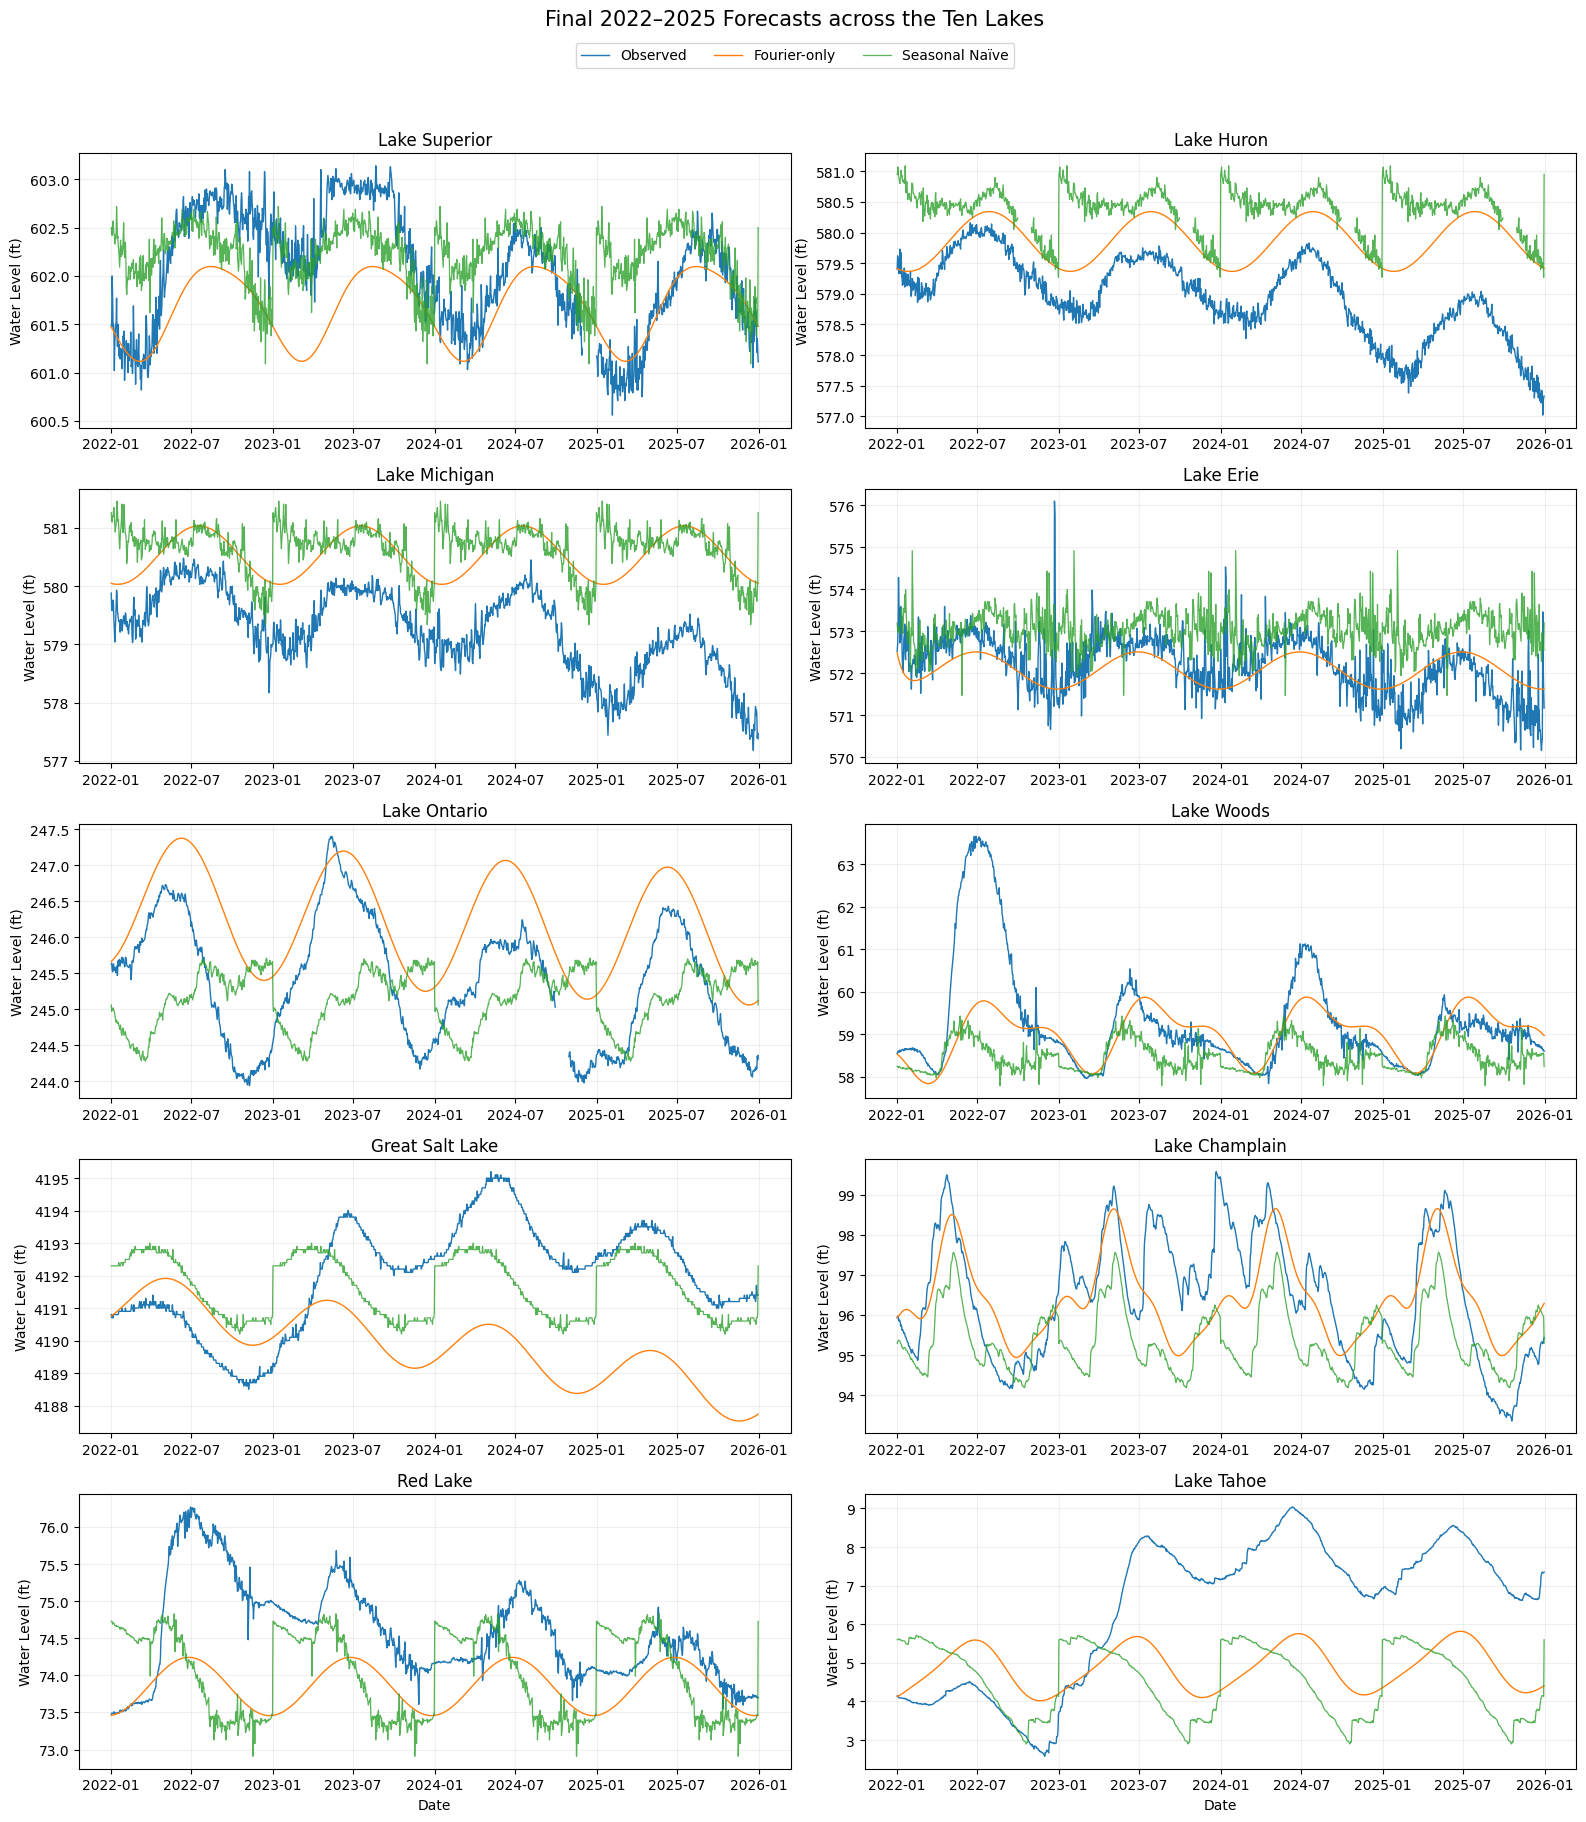

In [32]:
# Plot final-test forecasts for all ten lakes

if all_lake_final_results:

    fig, axes = plt.subplots(
        5,
        2,
        figsize=(16, 18),
        sharex=False
    )

    axes = axes.flatten()

    for ax, result in zip(
        axes,
        all_lake_final_results
    ):

        evaluation_data = result[
            "Evaluation Data"
        ]

        ax.plot(
            evaluation_data.index,
            evaluation_data["Actual"],
            label="Observed",
            linewidth=1.0
        )

        ax.plot(
            evaluation_data.index,
            evaluation_data["Model Forecast"],
            label=result["Model"],
            linewidth=1.0
        )

        ax.plot(
            evaluation_data.index,
            evaluation_data["Seasonal Naive"],
            label="Seasonal Naïve",
            linewidth=0.9,
            alpha=0.8
        )

        ax.set_title(
            result["Lake"]
        )

        ax.set_ylabel(
            "Water Level (ft)"
        )

        ax.grid(
            alpha=0.2
        )


    for ax in axes[-2:]:

        ax.set_xlabel(
            "Date"
        )


    handles, labels = (
        axes[0]
        .get_legend_handles_labels()
    )


    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,
        bbox_to_anchor=(0.5, 0.995)
    )


    fig.suptitle(
        "Final 2022–2025 Forecasts across the Ten Lakes",
        y=1.01,
        fontsize=15
    )


    plt.tight_layout(
        rect=[0, 0, 1, 0.97]
    )

    plt.show()

### 8.4 Residual diagnostics

Model adequacy was assessed using standardised one-step-ahead forecast errors from the final refitted SARIMAX models. Ljung–Box tests were evaluated at truncation lags of 7, 30 and 365 days, with degrees of freedom adjusted for the fitted non-seasonal AR and MA orders. Residual ACF plots were examined for lakes with at least one significant Ljung–Box result.

In [33]:
def get_standardized_forecast_errors(
    result
):
    """
    Extract finite standardised one-step-ahead
    forecast errors from the fitted SARIMAX model.

    Initial likelihood burn-in observations and
    dates with missing endogenous observations
    are excluded.
    """

    fitted_model = result[
        "Fitted Model"
    ]


  
    # Standardised one-step-ahead forecast errors
    # from the state-space representation
   

    standardized_errors = np.asarray(
        fitted_model
        .filter_results
        .standardized_forecasts_error[
            0
        ],
        dtype=float
    )


    # Original endogenous series used in the final refit.
    fitted_endog = np.asarray(
        fitted_model
        .model
        .endog,
        dtype=float
    ).reshape(
        -1
    )


    # Guard against any unexpected length mismatch.
    n_common = min(
        len(
            standardized_errors
        ),
        len(
            fitted_endog
        )
    )


    # Remove state-space initialisation burn-in.
    burn = int(
        getattr(
            fitted_model,
            "loglikelihood_burn",
            0
        )
        or 0
    )


    standardized_errors = (
        standardized_errors[
            burn:
            n_common
        ]
    )


    fitted_endog = (
        fitted_endog[
            burn:
            n_common
        ]
    )


    # Exclude dates where the endogenous observation
    # itself was missing and any non-finite error values.
    valid_mask = (
        np.isfinite(
            standardized_errors
        )
        & np.isfinite(
            fitted_endog
        )
    )


    standardized_errors = pd.Series(
        standardized_errors[
            valid_mask
        ],
        name=(
            "Standardized Forecast Error"
        )
    )


    return standardized_errors




# Ljung-Box residual diagnostics


cross_lake_ljung_box = []


requested_lags = [
    7,
    30,
    365
]


for result in all_lake_final_results:

    residuals = (
        get_standardized_forecast_errors(
            result
        )
    )


    p, d, q = tuple(
        result[
            "Best ARIMA"
        ]
    )


    # For the non-seasonal ARIMA error component,
    # adjust Ljung-Box degrees of freedom for
    # estimated AR and MA parameters.
    model_df = int(
        p + q
    )


    valid_lags = [
        lag
        for lag in requested_lags
        if (
            lag
            < len(
                residuals
            )
            and lag
            > model_df
        )
    ]


    if not valid_lags:
        continue


    lb_result = (
        acorr_ljungbox(
            residuals,
            lags=valid_lags,
            model_df=model_df,
            return_df=True
        )
    )


    for lag in valid_lags:

        lb_statistic = (
            lb_result.loc[
                lag,
                "lb_stat"
            ]
        )

        p_value = (
            lb_result.loc[
                lag,
                "lb_pvalue"
            ]
        )


        cross_lake_ljung_box.append({
            "Lake":
                result[
                    "Lake"
                ],

            "Lag":
                lag,

            "Model df":
                model_df,

            "Residual N":
                len(
                    residuals
                ),

            "LB Statistic":
                lb_statistic,

            "p-value":
                p_value,

            "Significant":
                (
                    pd.notna(
                        p_value
                    )
                    and p_value < 0.05
                )
        })


cross_lake_ljung_box_df = pd.DataFrame(
    cross_lake_ljung_box
)


display(
    cross_lake_ljung_box_df
)

,Lake,Lag,Model df,Residual N,LB Statistic,p-value,Significant
0,Lake Superior,7,0,5842,708.960021,8.067809e-149,True
1,Lake Superior,30,0,5842,759.799808,1.595108e-140,True
2,Lake Superior,365,0,5842,1196.171619,5.051599e-89,True
3,Lake Huron,7,1,5811,240.295628,4.853981e-49,True
4,Lake Huron,30,1,5811,290.038709,7.529752e-45,True
5,Lake Huron,365,1,5811,665.681291,5.634031e-20,True
6,Lake Michigan,7,0,5842,871.143345,8.169457e-184,True
7,Lake Michigan,30,0,5842,920.228105,3.373679e-174,True
8,Lake Michigan,365,0,5842,1322.657333,1.389830e-108,True
9,Lake Erie,7,2,5842,311.642049,3.142430e-65,True


Lakes requiring residual ACF inspection: ['Lake Superior', 'Lake Huron', 'Lake Michigan', 'Lake Erie', 'Lake Ontario', 'Lake Woods', 'Great Salt Lake', 'Lake Champlain', 'Red Lake', 'Lake Tahoe']


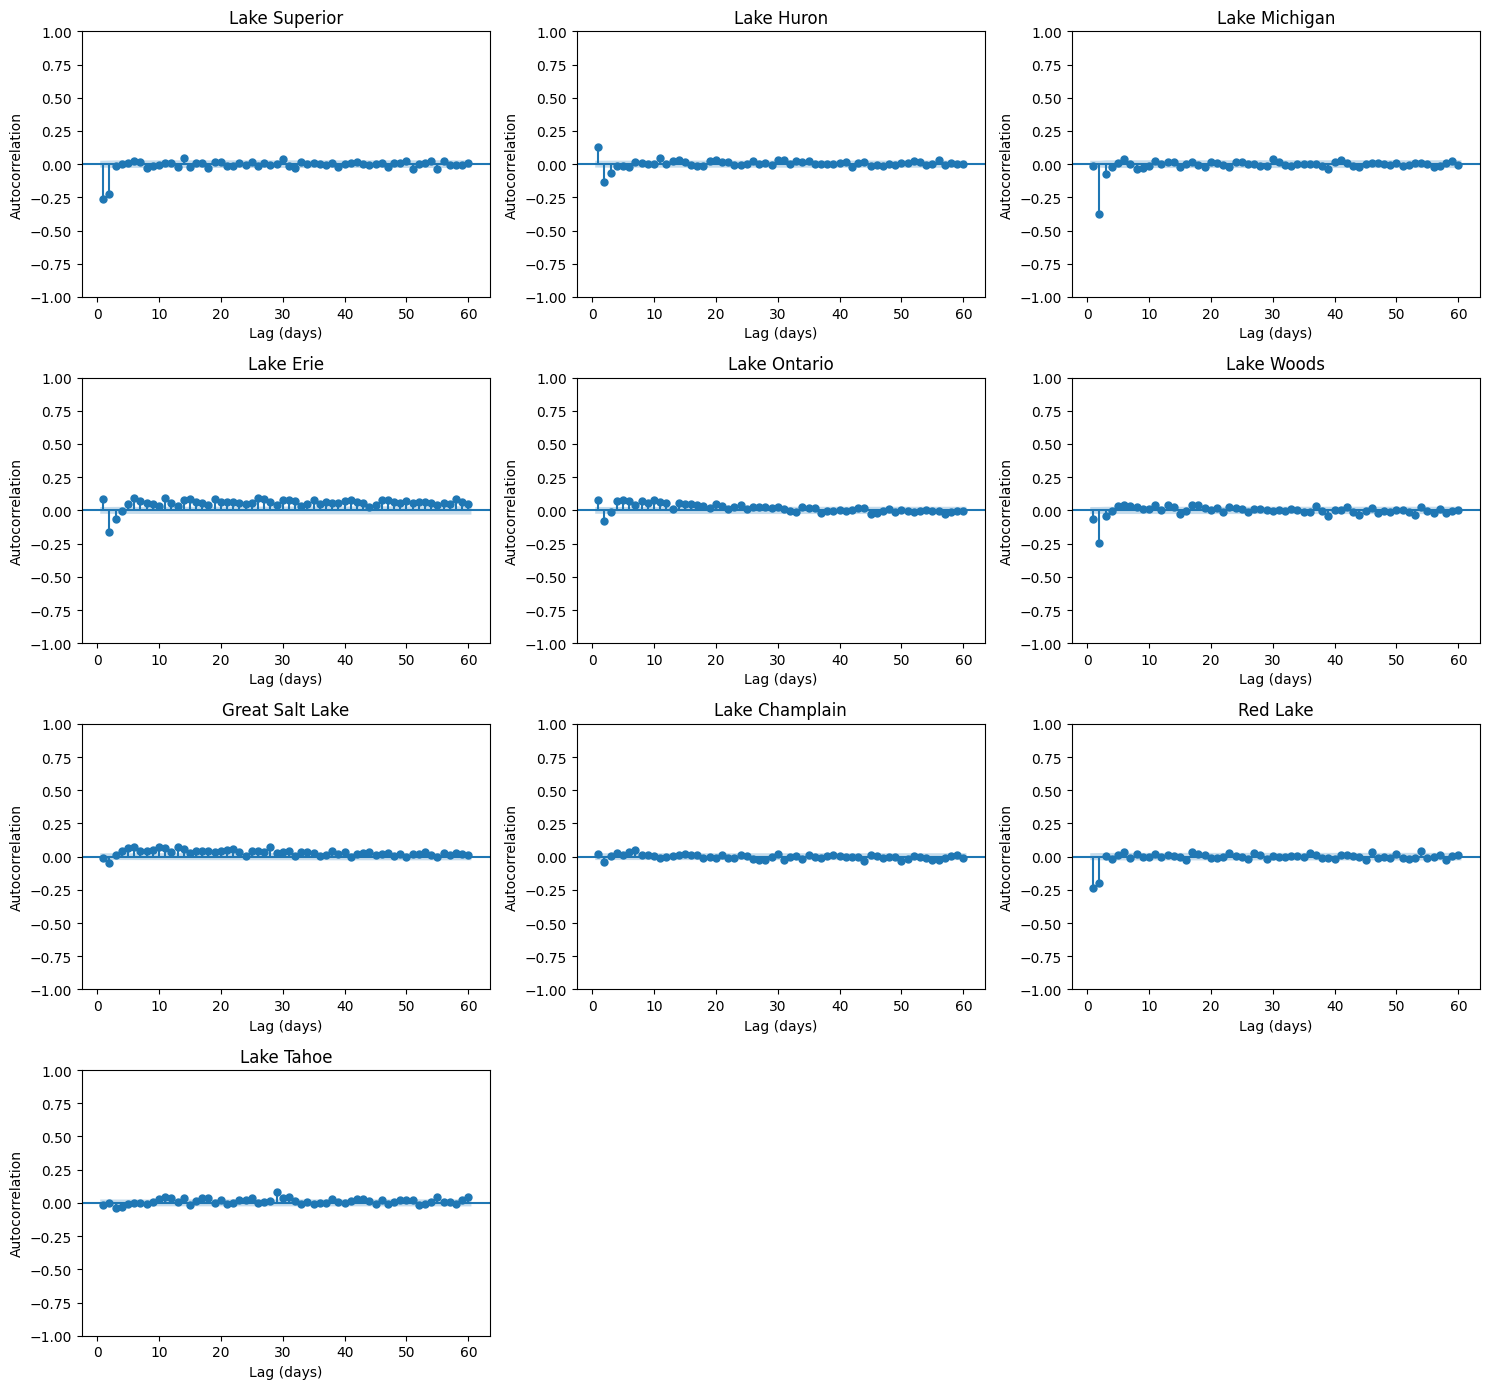

In [34]:
# Residual ACF inspection

import math

if not cross_lake_ljung_box_df.empty:

    diagnostic_lakes = (
        cross_lake_ljung_box_df[
            cross_lake_ljung_box_df[
                "Significant"
            ]
        ][
            "Lake"
        ]
        .drop_duplicates()
        .tolist()
    )

else:

    diagnostic_lakes = []


print(
    "Lakes requiring residual ACF inspection:",
    diagnostic_lakes
)



# Combined residual ACF figure


if diagnostic_lakes:

    n_lakes = len(
        diagnostic_lakes
    )

    n_cols = 3

    n_rows = math.ceil(
        n_lakes / n_cols
    )


    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(
            15,
            3.5 * n_rows
        )
    )


    axes = np.array(
        axes
    ).reshape(-1)


    for i, lake_name in enumerate(
        diagnostic_lakes
    ):

        lake_result = next(
            result
            for result
            in all_lake_final_results
            if (
                result[
                    "Lake"
                ]
                == lake_name
            )
        )


        residuals = (
            get_standardized_forecast_errors(
                lake_result
            )
        )


        if len(
            residuals
        ) < 2:

            axes[i].set_visible(
                False
            )

            continue


        plot_acf(
            residuals,
            lags=min(
                60,
                len(
                    residuals
                )
                - 1
            ),
            zero=False,
            ax=axes[i]
        )


        axes[i].set_title(
            lake_name
        )

        axes[i].set_xlabel(
            "Lag (days)"
        )

        axes[i].set_ylabel(
            "Autocorrelation"
        )


    # Hide unused panels
    for j in range(
        n_lakes,
        len(
            axes
        )
    ):

        axes[j].set_visible(
            False
        )


    plt.tight_layout()


    plt.savefig(
        figures_path
        / "Figure_standardised_forecast_error_acf.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

## 9. Candidate Failure Audit

In [35]:
# Audit unsuccessful candidate models.

failed_fourier_candidates = (
    fourier_candidate_grid_all_lakes[
        fourier_candidate_grid_all_lakes[
            "Status"
        ]
        != "Success"
    ]
    .copy()
)


failed_climate_candidates = (
    climate_candidate_validation_all_lakes[
        climate_candidate_validation_all_lakes[
            "Status"
        ]
        != "Success"
    ]
    .copy()
)


print(
    "Failed Fourier-SARIMAX candidates:",
    len(
        failed_fourier_candidates
    )
)

print(
    "Failed climate-SARIMAX candidates:",
    len(
        failed_climate_candidates
    )
)


if not failed_fourier_candidates.empty:

    print(
        "\nFourier-SARIMAX candidate failures:"
    )

    display(
        failed_fourier_candidates[
            [
                "Lake",
                "Order",
                "Fourier K",
                "Status",
                "Error"
            ]
        ]
    )


if not failed_climate_candidates.empty:

    print(
        "\nClimate-SARIMAX candidate failures:"
    )

    display(
        failed_climate_candidates[
            [
                "Lake",
                "Model",
                "Status",
                "Error"
            ]
        ]
    )

Failed Fourier-SARIMAX candidates: 12
Failed climate-SARIMAX candidates: 6

Fourier-SARIMAX candidate failures:


,Lake,Order,Fourier K,Status,Error
259,Lake Ontario,"(2, 0, 1)",2,Failed,Forecast is numerically explosive.
260,Lake Ontario,"(2, 0, 1)",3,Failed,Forecast is numerically explosive.
261,Lake Ontario,"(2, 0, 1)",4,Failed,Forecast is numerically explosive.
262,Lake Ontario,"(2, 0, 1)",5,Failed,Forecast is numerically explosive.
263,Lake Ontario,"(2, 0, 1)",6,Failed,Forecast is numerically explosive.
313,Lake Woods,"(2, 0, 1)",2,Failed,L-BFGS did not converge. Powell did not converge.
317,Lake Woods,"(2, 0, 1)",6,Failed,L-BFGS did not converge. Powell did not converge.
370,Great Salt Lake,"(2, 0, 1)",5,Failed,Forecast is numerically explosive.
371,Great Salt Lake,"(2, 0, 1)",6,Failed,Forecast is numerically explosive.
375,Great Salt Lake,"(2, 0, 2)",4,Failed,Forecast is numerically explosive.



Climate-SARIMAX candidate failures:


,Lake,Model,Status,Error
4,Lake Huron,Climate-contemporaneous,Failed,Internal missing exogenous values in Lake Huro...
5,Lake Huron,Climate-lagged,Failed,Missing forecast exogenous values in Lake Huro...
16,Lake Woods,Climate-contemporaneous,Failed,Internal missing exogenous values in Lake Wood...
17,Lake Woods,Climate-lagged,Failed,Internal missing exogenous values in Lake Wood...
25,Red Lake,Climate-contemporaneous,Failed,Internal missing exogenous values in Red Lake ...
26,Red Lake,Climate-lagged,Failed,Internal missing exogenous values in Red Lake ...


In [36]:
# Pre-export integrity checks

assert len(
    fourier_selection_summary
) == 10, (
    "Fourier-SARIMAX selection is incomplete."
)


assert len(
    all_lake_model_selection
) == 10, (
    "Final validation-based model selection "
    "is incomplete."
)


if final_evaluation_failures:

    raise RuntimeError(
        "Export blocked because at least one "
        "final out-of-sample evaluation failed. "
        "Inspect final_evaluation_failures first."
    )


assert len(
    all_lake_final_results
) == 10, (
    "Export blocked because final results "
    "are not available for all ten lakes."
)


assert len(
    cross_lake_final_summary
) == 10, (
    "Export blocked because the cross-lake "
    "final summary does not contain ten lakes."
)


assert (
    set(
        cross_lake_final_summary[
            "Lake"
        ]
    )
    == set(
        lake_order
    )
), (
    "Export blocked because the final summary "
    "does not contain the expected ten lakes."
)


assert (
    test_count_check[
        "Match"
    ]
    .all()
), (
    "Export blocked because at least one "
    "SARIMAX model is not evaluated on every "
    "available observed final-test water level."
)


assert (
    cross_lake_final_summary[
        [
            "RMSE",
            "MAE",
            "R2",
            "NRMSE",
            "N_test"
        ]
    ]
    .notna()
    .all()
    .all()
), (
    "Export blocked because final forecasting "
    "metrics contain missing values."
)


print(
    "All pre-export integrity checks passed."
)

All pre-export integrity checks passed.


## 10. Export Reproducibility Outputs

In [37]:
if final_evaluation_failures:

    raise RuntimeError(
        "Export blocked because final evaluation "
        "failures remain."
    )


if len(
    all_lake_final_results
) != 10:

    raise RuntimeError(
        "Export blocked because final forecasting "
        "results are incomplete."
    )


if not (
    test_count_check[
        "Match"
    ]
    .all()
):

    raise RuntimeError(
        "Export blocked because the final-test "
        "observation-count QC has not passed."
    )





adf_summary.to_csv(
    forecast_output_dir
    / "time_series_adf_summary.csv",
    index=False
)

seasonal_decomposition_summary.to_csv(
    forecast_output_dir
    / "seasonal_decomposition_segments.csv",
    index=False
)

fourier_selection_summary.to_csv(
    forecast_output_dir
    / "all_lakes_fourier_sarimax_selection.csv",
    index=False
)

fourier_candidate_grid_all_lakes.to_csv(
    forecast_output_dir
    / "all_lakes_fourier_candidate_grid.csv",
    index=False
)

training_ccf_lag_summary.to_csv(
    forecast_output_dir
    / "training_only_climate_lag_selection.csv",
    index=False
)

all_lake_model_selection.to_csv(
    forecast_output_dir
    / "all_lakes_final_model_selection.csv",
    index=False
)

climate_candidate_validation_all_lakes.to_csv(
    forecast_output_dir
    / "all_lakes_climate_candidate_validation.csv",
    index=False
)

cross_lake_final_summary.to_csv(
    forecast_output_dir
    / "all_lakes_final_test_results.csv",
    index=False
)

cross_lake_ljung_box_df.to_csv(
    forecast_output_dir
    / "all_lakes_ljung_box_results.csv",
    index=False
)

if final_evaluation_failures:
    pd.DataFrame(
        final_evaluation_failures
    ).to_csv(
        forecast_output_dir
        / "final_evaluation_failures.csv",
        index=False
    )

for result in all_lake_final_results:

    safe_lake_name = (
        result["Lake"]
        .lower()
        .replace(" ", "_")
    )

    forecast_export = pd.DataFrame({
        "Observed": result["Observed"],
        "Forecast": result["Forecast"],
        "Seasonal_Naive": result["Naive Forecast"]
    })

    forecast_export.to_csv(
        forecast_output_dir
        / f"{safe_lake_name}_final_daily_forecasts.csv",
        index=True
    )


if not wesd_lake_summary.empty:
    wesd_lake_summary.to_csv(
        forecast_output_dir
        / "wesd_lake_coverage_summary.csv",
        index=False
    )

    wesd_yearly_coverage.to_csv(
        forecast_output_dir
        / "wesd_yearly_coverage_summary.csv",
        index=False
    )

print(
    "Forecasting outputs saved to:",
    forecast_output_dir.resolve()
)

Forecasting outputs saved to: D:\Postgraduate\DATA72000 Data Science Extended Research Project\ERP Final\outputs\forecasting_results
